# 서울시 자치구 안전부담점수 최종 분석 노트북

이 노트북은 원본 `safety_crimes_dispatch_eda_10ideas.ipynb`의 핵심 흐름을 보존한 정리본입니다. 원본의 전처리, `분석 아이디어 1~10`, 원본 가중치 민감도 분석, 추가 EDA/통계검정/사후검정을 가져오고, 마지막에 안전부담점수 데이터 검증 절차를 추가했습니다.

실행 순서는 위에서 아래로 진행하면 됩니다. 표와 검증 지표는 보고서 가독성을 위해 소수점 2자리 중심으로 표시합니다.


## 전처리 1. 데이터 로드와 인코딩 자동 선택

두 CSV 파일을 `safety_analystic_data` 상대 경로에서 읽습니다. 한글 컬럼과 자치구명이 깨질 수 있으므로 여러 인코딩 후보를 시도하고, 한글이 가장 많이 복원되는 인코딩을 선택합니다.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

def set_korean_font():
    from matplotlib import font_manager, rcParams

    font_candidates = [
        'Malgun Gothic',
        '맑은 고딕',
        'AppleGothic',
        'NanumGothic',
        'Noto Sans CJK KR',
        'Noto Sans KR',
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            rcParams['font.family'] = font_name
            rcParams['axes.unicode_minus'] = False
            print(f'한글 폰트 설정: {font_name}')
            return font_name

    rcParams['axes.unicode_minus'] = False
    print('사용 가능한 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 Malgun Gothic 또는 NanumGothic을 설치/등록하세요.')
    return None

set_korean_font()

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / 'branch_SG' / 'safety_analystic' / 'safety_analystic_data').exists():
            return candidate
        if candidate.name == 'safety_analystic' and (candidate / 'safety_analystic_data').exists():
            return candidate.parents[1]
    raise FileNotFoundError('safety_analystic_data 폴더를 찾을 수 없습니다. 노트북을 저장소 내부에서 실행하세요.')

BASE_DIR = find_project_root()
SAFETY_DIR = BASE_DIR / 'branch_SG' / 'safety_analystic'
DATA_DIR = SAFETY_DIR / 'safety_analystic_data'
OUTPUT_DIR = SAFETY_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CRIMES_PATH = DATA_DIR / '_5_crimes__202604231451.csv'
DISPATCH_PATH = DATA_DIR / 'dispatch_integrated_202604231451.csv'
POPULATION_PATH = DATA_DIR / 'Garbage_collection_status.csv'

print(f'프로젝트 루트: {BASE_DIR}')
print(f'안전 데이터 폴더: {DATA_DIR}')

def hangul_score(df):
    text = ' '.join(map(str, list(df.columns) + df.head(3).astype(str).values.ravel().tolist()))
    return sum('가' <= ch <= '힣' for ch in text)

def read_csv_best(path):
    candidates = []
    for enc in ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']:
        try:
            df = pd.read_csv(path, encoding=enc)
            candidates.append((hangul_score(df), enc, df))
        except UnicodeDecodeError:
            continue
    if not candidates:
        raise ValueError(f'읽을 수 있는 인코딩을 찾지 못했습니다: {path}')
    score, enc, df = max(candidates, key=lambda x: x[0])
    print(f'{path.name}: encoding={enc}, shape={df.shape}, hangul_score={score}')
    return df

crimes_raw = read_csv_best(CRIMES_PATH)
dispatch_raw = read_csv_best(DISPATCH_PATH)
population_raw = read_csv_best(POPULATION_PATH)

display(crimes_raw.head())
display(dispatch_raw.head())
display(population_raw.head())


한글 폰트 설정: Malgun Gothic
프로젝트 루트: c:\8ssible-Healing-Seoul-Analysis
안전 데이터 폴더: c:\8ssible-Healing-Seoul-Analysis\branch_SG\safety_analystic\safety_analystic_data
_5_crimes__202604231451.csv: encoding=utf-8-sig, shape=(26, 7), hangul_score=22
dispatch_integrated_202604231451.csv: encoding=utf-8-sig, shape=(25, 110), hangul_score=11
Garbage_collection_status.csv: encoding=utf-8-sig, shape=(26, 22), hangul_score=160


,자치구,발생(2022),검거(2022),발생(2023),검거(2023),발생(2024),검거(2024)
0,소계,90399,65097,86213,64823,80819,63275
1,종로구,3138,3284,2981,3485,2765,3248
2,중구,3071,2119,3348,2465,2955,2180
3,용산구,2967,2093,3021,2268,3322,2475
4,성동구,2194,1597,2023,1411,2117,1510


,gu_code,자치구,2201_ed,2201_rp,2201_fd,2202_ed,2202_rp,2202_fd,2203_ed,2203_rp,...,2409_fd,2410_ed,2410_rp,2410_fd,2411_ed,2411_rp,2411_fd,2412_ed,2412_rp,2412_fd
0,11110,종로구,1172,NaN,14,1195,NaN,15,1514,378,...,17,1285,242,21,1307,287,19,1414,224,17
1,11140,중구,1327,NaN,20,1242,NaN,25,1482,300,...,14,1360,248,15,1289,269,18,1332,207,16
2,11170,용산구,1260,NaN,22,1160,NaN,7,1472,446,...,14,1361,362,14,1260,390,14,1357,296,14
3,11200,성동구,1310,NaN,17,1384,NaN,21,1717,515,...,7,1277,213,9,1174,237,10,1325,294,24
4,11215,광진구,1539,NaN,16,1487,NaN,10,1896,500,...,21,1459,401,25,1339,300,13,1479,358,29


,자치구,2022_행정구역(A)_면적 (km²),2022_행정구역(A)_인구 (명),2022_청소구역(B)_면적 (km²),2022_청소구역(B)_인구 (명),2022_처리방법 (톤/년)_소계,2022_처리방법 (톤/년)_매립,2022_처리방법 (톤/년)_소각,2023_행정구역(A)_면적 (km²),2023_행정구역(A)_인구 (명),...,2023_처리방법 (톤/년)_소계,2023_처리방법 (톤/년)_매립,2023_처리방법 (톤/년)_소각,2024_행정구역(A)_면적 (km²),2024_행정구역(A)_인구 (명),2024_청소구역(B)_면적 (km²),2024_청소구역(B)_인구 (명),2024_처리방법 (톤/년)_소계,2024_처리방법 (톤/년)_매립,2024_처리방법 (톤/년)_소각
0,소계,605.21,9667669,605.21,9667669,1.590432e+07,431348.39853,971704.040044,605.20,9638799,...,1.374121e+07,343719.49013,1.032403e+06,605.25,9597372,605.25,9597372,1.409548e+07,287640.66289,1049468.662
1,종로구,23.91,152211,23.91,152211,3.880167e+05,7125.50000,41873.419394,23.91,150453,...,3.262330e+05,6172.50000,4.053225e+04,23.91,149608,23.91,149608,2.805180e+05,4060.71000,40085.742
2,중구,9.96,130785,9.96,130785,4.418359e+05,8793.06000,45657.150932,9.96,131793,...,3.491385e+05,6945.73000,4.704887e+04,9.96,131214,9.96,131214,4.632012e+05,4812.94800,43340.320
3,용산구,21.87,233284,21.87,233284,9.497071e+05,6981.03000,34096.456543,21.87,227106,...,8.618236e+05,5123.66000,3.437032e+04,21.87,217194,21.87,217194,4.240469e+05,3751.57000,33854.660
4,성동구,16.82,288234,16.82,288234,1.087034e+06,33898.40000,29292.226487,16.82,284766,...,9.504809e+05,12525.10000,3.724503e+04,16.86,281289,16.86,281289,1.027416e+06,6383.06000,35877.640


## 전처리 2. 컬럼명 표준화와 숫자형 변환

범죄 데이터는 `자치구-연도-발생/검거` 형태로 정리하고, 출동 데이터는 `YYMM_지표` 컬럼을 월별 long format으로 변환합니다.

In [2]:
def clean_text(s):
    return str(s).strip().replace('\ufeff', '')

def to_number(s):
    return pd.to_numeric(pd.Series(s).astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')

crimes = crimes_raw.copy()
crimes.columns = [clean_text(c) for c in crimes.columns]
crimes = crimes.rename(columns={crimes.columns[0]: '자치구'})

crime_rows = []
for _, row in crimes.iterrows():
    district = clean_text(row['자치구'])
    for col in crimes.columns[1:]:
        m = re.search(r'(발생|검거).*?(20\d{2})', col)
        if m:
            crime_rows.append({'자치구': district, '연도': int(m.group(2)), '구분': m.group(1), '값': row[col]})

crime_long = pd.DataFrame(crime_rows)
crime_long['값'] = to_number(crime_long['값'])
crime_yearly = crime_long.pivot_table(index=['자치구', '연도'], columns='구분', values='값', aggfunc='sum').reset_index().rename_axis(None, axis=1)
crime_yearly['검거율'] = np.where(crime_yearly['발생'] > 0, crime_yearly['검거'] / crime_yearly['발생'], np.nan)

dispatch = dispatch_raw.copy()
dispatch.columns = [clean_text(c) for c in dispatch.columns]
dispatch = dispatch.rename(columns={dispatch.columns[0]: 'gu_code', dispatch.columns[1]: '자치구'})

dispatch_rows = []
for _, row in dispatch.iterrows():
    for col in dispatch.columns[2:]:
        m = re.fullmatch(r'(\d{2})(\d{2})_(ed|rp|fd)', col)
        if m:
            yy, mm, metric = m.groups()
            dispatch_rows.append({'gu_code': row['gu_code'], '자치구': clean_text(row['자치구']), '연도': 2000 + int(yy), '월': int(mm), '지표': metric, '값': row[col]})

dispatch_long = pd.DataFrame(dispatch_rows)
dispatch_long['값'] = to_number(dispatch_long['값'])
dispatch_monthly = dispatch_long.pivot_table(index=['gu_code', '자치구', '연도', '월'], columns='지표', values='값', aggfunc=lambda x: x.sum(min_count=1)).reset_index().rename_axis(None, axis=1)
dispatch_metric_names = {'ed': '응급출동', 'fd': '화재출동', 'rp': '구조출동'}
dispatch_monthly = dispatch_monthly.rename(columns=dispatch_metric_names)
for col in dispatch_metric_names.values():
    if col not in dispatch_monthly.columns:
        dispatch_monthly[col] = np.nan

display(crime_yearly.head())
display(dispatch_monthly.head())

,자치구,연도,검거,발생,검거율
0,강남구,2022,5020,6947,0.722614
1,강남구,2023,4992,6763,0.738134
2,강남구,2024,4570,6107,0.748322
3,강동구,2022,2644,3711,0.712476
4,강동구,2023,2495,3398,0.734255


,gu_code,자치구,연도,월,응급출동,화재출동,구조출동
0,11110,종로구,2022,1,1172.0,14.0,NaN
1,11110,종로구,2022,2,1195.0,15.0,NaN
2,11110,종로구,2022,3,1514.0,17.0,378.0
3,11110,종로구,2022,4,1362.0,15.0,305.0
4,11110,종로구,2022,5,1576.0,20.0,402.0


## 전처리 3. 자치구 매칭, 결측치 점검, 분석용 병합 테이블 생성

합계/소계 행을 제외하고 범죄 연도별 데이터와 출동 연도별 데이터를 자치구·연도 기준으로 결합합니다. `구조출동` 결측은 0으로 숨기지 않고 유지하며, 관측 월수와 12개월 환산 지표를 별도로 만들어 이후 분석에서 원자료와 보정값을 구분합니다.

In [3]:
TOTAL_NAMES = {'합계', '소계', '총계', '전체'}
crime_yearly = crime_yearly[~crime_yearly['자치구'].isin(TOTAL_NAMES)].copy()
dispatch_monthly = dispatch_monthly[~dispatch_monthly['자치구'].isin(TOTAL_NAMES)].copy()

dispatch_monthly['구조출동_결측여부'] = dispatch_monthly['구조출동'].isna()
dispatch_monthly['총출동지표_관측합계'] = dispatch_monthly[['응급출동', '구조출동', '화재출동']].sum(axis=1, min_count=1)
dispatch_monthly['총출동지표'] = dispatch_monthly['총출동지표_관측합계']
dispatch_monthly['구조출동_월평균'] = dispatch_monthly.groupby(['gu_code', '자치구', '연도'])['구조출동'].transform('mean')
dispatch_monthly['구조출동_월보정'] = dispatch_monthly['구조출동'].fillna(dispatch_monthly['구조출동_월평균'])
dispatch_monthly['총출동지표_월보정'] = dispatch_monthly[['응급출동', '구조출동_월보정', '화재출동']].sum(axis=1, min_count=1)

dispatch_yearly = dispatch_monthly.groupby(['gu_code', '자치구', '연도'], as_index=False).agg(
    응급출동=('응급출동', lambda x: x.sum(min_count=1)),
    구조출동=('구조출동', lambda x: x.sum(min_count=1)),
    화재출동=('화재출동', lambda x: x.sum(min_count=1)),
    총출동지표_관측합계=('총출동지표_관측합계', lambda x: x.sum(min_count=1)),
    구조출동_관측월수=('구조출동', 'count'),
    구조출동_결측월수=('구조출동_결측여부', 'sum'),
)
dispatch_yearly['구조출동_12개월환산'] = np.where(
    dispatch_yearly['구조출동_관측월수'] > 0,
    dispatch_yearly['구조출동'] / dispatch_yearly['구조출동_관측월수'] * 12,
    np.nan,
)
dispatch_yearly['총출동지표_12개월환산'] = dispatch_yearly['응급출동'] + dispatch_yearly['화재출동'] + dispatch_yearly['구조출동_12개월환산']
dispatch_yearly['총출동지표'] = dispatch_yearly['총출동지표_관측합계']

population_cols = [col for col in population_raw.columns if '행정구역(A)_인구' in col]
population_yearly = (
    population_raw[population_raw['자치구'].ne('소계')]
    .melt(id_vars='자치구', value_vars=population_cols, var_name='연도', value_name='주민등록인구')
)
population_yearly['연도'] = population_yearly['연도'].str.extract(r'(\d{4})').astype(int)
population_yearly['주민등록인구'] = pd.to_numeric(population_yearly['주민등록인구'], errors='coerce')

merged = crime_yearly.merge(dispatch_yearly, on=['자치구', '연도'], how='outer')
merged = merged.merge(population_yearly, on=['자치구', '연도'], how='left')
merged['검거율'] = np.where(merged['발생'] > 0, merged['검거'] / merged['발생'], np.nan)
merged['발생_1만명당'] = np.where(merged['주민등록인구'] > 0, merged['발생'] / merged['주민등록인구'] * 10000, np.nan)
merged['총출동지표_12개월환산_1만명당'] = np.where(merged['주민등록인구'] > 0, merged['총출동지표_12개월환산'] / merged['주민등록인구'] * 10000, np.nan)

print('crime_yearly:', crime_yearly.shape)
print('dispatch_monthly:', dispatch_monthly.shape)
print('dispatch_yearly:', dispatch_yearly.shape)
print('merged:', merged.shape)

display(dispatch_yearly.groupby('연도', as_index=False)[['구조출동_관측월수', '구조출동_결측월수']].sum())
display(merged.isna().sum().to_frame('missing_count'))
display(merged.head())

crime_yearly: (75, 5)
dispatch_monthly: (900, 13)
dispatch_yearly: (75, 12)
merged: (75, 18)


,연도,구조출동_관측월수,구조출동_결측월수
0,2022,250,50
1,2023,300,0
2,2024,300,0


,missing_count
자치구,0
연도,0
검거,0
발생,0
검거율,0
gu_code,0
응급출동,0
구조출동,0
화재출동,0
총출동지표_관측합계,0


,자치구,연도,검거,발생,검거율,gu_code,응급출동,구조출동,화재출동,총출동지표_관측합계,구조출동_관측월수,구조출동_결측월수,구조출동_12개월환산,총출동지표_12개월환산,총출동지표,주민등록인구,발생_1만명당,총출동지표_12개월환산_1만명당
0,강남구,2022,5020,6947,0.722614,11680,38601.0,10413.0,437.0,49451.0,10,2,12495.6,51533.6,49451.0,534103,130.068545,964.862583
1,강남구,2023,4992,6763,0.738134,11680,38950.0,11071.0,422.0,50443.0,12,0,11071.0,50443.0,50443.0,550282,122.900622,916.675450
2,강남구,2024,4570,6107,0.748322,11680,35813.0,10566.0,387.0,46766.0,12,0,10566.0,46766.0,46766.0,563215,108.431061,830.340101
3,강동구,2022,2644,3711,0.712476,11740,25391.0,4598.0,194.0,30183.0,10,2,5517.6,31102.6,30183.0,464037,79.972071,670.261208
4,강동구,2023,2495,3398,0.734255,11740,25100.0,4805.0,171.0,30076.0,12,0,4805.0,30076.0,30076.0,463318,73.340557,649.143785


## 분석 아이디어 1. 자치구별 범죄 발생 추세

2022~2024년 자치구별 범죄 발생 건수가 증가하는지, 감소하는지, 특정 연도에 튀는지 확인합니다.

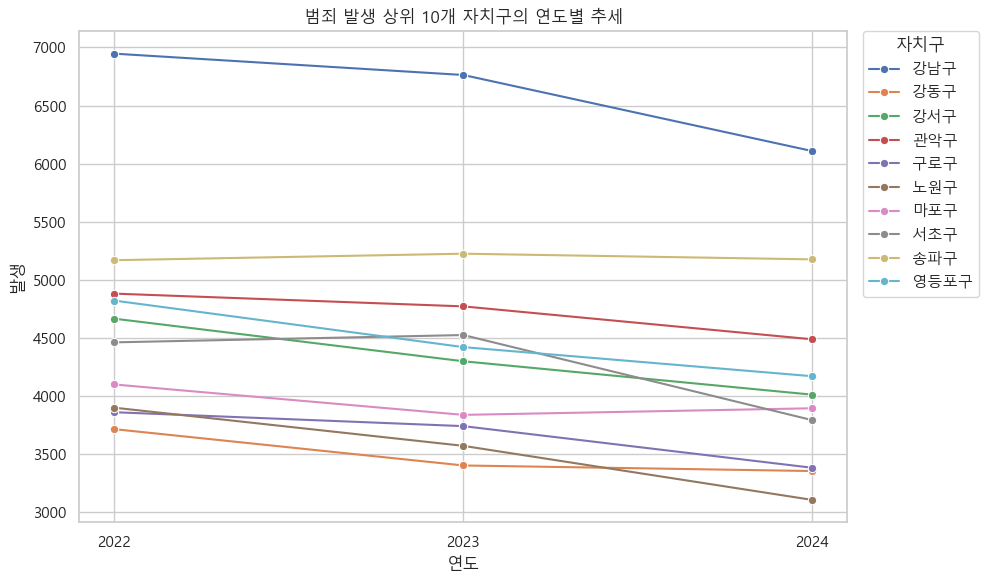

연도,2022,2023,2024,평균
자치구,,,,
강남구,6947.0,6763.0,6107.0,6605.666667
송파구,5167.0,5223.0,5174.0,5188.000000
관악구,4879.0,4769.0,4485.0,4711.000000
영등포구,4819.0,4418.0,4167.0,4468.000000
강서구,4663.0,4296.0,4008.0,4322.333333
서초구,4459.0,4522.0,3788.0,4256.333333
마포구,4096.0,3834.0,3891.0,3940.333333
구로구,3857.0,3737.0,3378.0,3657.333333
노원구,3896.0,3567.0,3101.0,3521.333333


In [4]:
plot_df = crime_yearly.dropna(subset=['발생']).copy()
top_districts = plot_df.groupby('자치구')['발생'].mean().sort_values(ascending=False).head(10).index
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=plot_df[plot_df['자치구'].isin(top_districts)], x='연도', y='발생', hue='자치구', marker='o')
plt.title('범죄 발생 상위 10개 자치구의 연도별 추세')
plt.xticks(sorted(plot_df['연도'].dropna().unique()))
ax.legend(title='자치구', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()
display(plot_df.pivot_table(index='자치구', columns='연도', values='발생').assign(평균=lambda d: d.mean(axis=1)).sort_values('평균', ascending=False).head(10))

## 분석 아이디어 2. 검거율 분석

발생 대비 검거 비율을 계산해 범죄 규모와 대응 성과를 함께 봅니다.

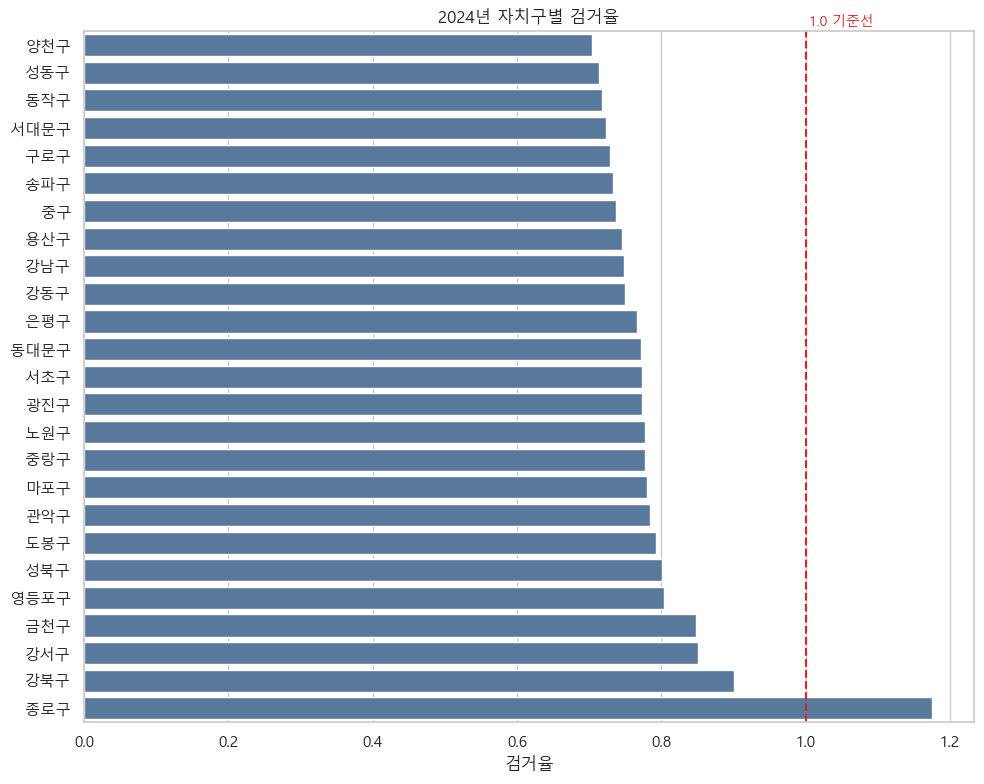

,자치구,발생,검거,검거율
59,양천구,3000,2113,0.704333
47,성동구,2117,1510,0.713274
35,동작구,2454,1760,0.717196
41,서대문구,2054,1486,0.723466
20,구로구,3378,2463,0.729130
56,송파구,5174,3790,0.732509
74,중구,2955,2180,0.737733
65,용산구,3322,2475,0.745033
2,강남구,6107,4570,0.748322
5,강동구,3350,2510,0.749254


In [5]:
plot_df = crime_yearly.dropna(subset=['검거율']).copy()
latest_year = int(plot_df['연도'].max())
latest = plot_df[plot_df['연도'] == latest_year].sort_values('검거율')
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=latest, x='검거율', y='자치구', color='#4C78A8')
ax.axvline(1, color='#D62728', linestyle='--', linewidth=1.5)
ax.text(1.005, -0.6, '1.0 기준선', color='#D62728', va='bottom', fontsize=10)
plt.title(f'{latest_year}년 자치구별 검거율')
plt.xlabel('검거율')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(latest[['자치구', '발생', '검거', '검거율']].head(10))

## 분석 아이디어 3. 범죄 발생과 출동량의 관계

범죄 발생이 많은 자치구일수록 출동 지표도 높은지 산점도와 상관계수로 확인합니다.

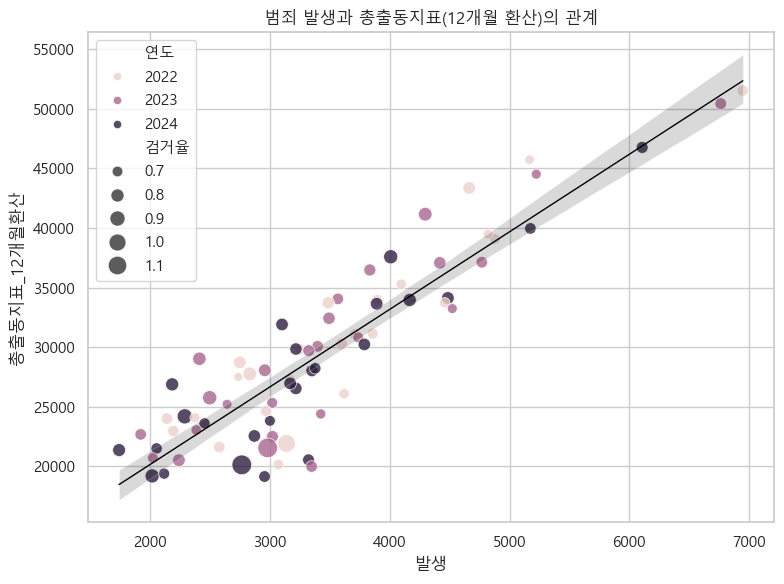

,발생,검거율,응급출동,구조출동,구조출동_12개월환산,화재출동,총출동지표_12개월환산
발생,1.000000,-0.178031,0.874303,0.892777,0.904676,0.749910,0.902885
검거율,-0.178031,1.000000,-0.207808,-0.171699,-0.224868,-0.034680,-0.215933
응급출동,0.874303,-0.207808,1.000000,0.874875,0.885232,0.729537,0.991916
구조출동,0.892777,-0.171699,0.874875,1.000000,0.969415,0.866863,0.921517
구조출동_12개월환산,0.904676,-0.224868,0.885232,0.969415,1.000000,0.828017,0.937055
화재출동,0.749910,-0.034680,0.729537,0.866863,0.828017,1.000000,0.776105
총출동지표_12개월환산,0.902885,-0.215933,0.991916,0.921517,0.937055,0.776105,1.000000


In [6]:
plot_df = merged.dropna(subset=['발생', '총출동지표_12개월환산']).copy()
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='발생', y='총출동지표_12개월환산', hue='연도', size='검거율', sizes=(40, 200), alpha=0.8)
sns.regplot(data=plot_df, x='발생', y='총출동지표_12개월환산', scatter=False, color='black', line_kws={'linewidth': 1})
plt.title('범죄 발생과 총출동지표(12개월 환산)의 관계')
plt.ylabel('총출동지표_12개월환산')
plt.tight_layout()
plt.show()
display(plot_df[['발생', '검거율', '응급출동', '구조출동', '구조출동_12개월환산', '화재출동', '총출동지표_12개월환산']].corr(numeric_only=True))

## 분석 아이디어 4. 월별 출동 패턴 분석

월별 출동 지표를 서울 전체 합계로 집계해 계절성이나 특정 월의 급증을 살펴봅니다. `구조출동` 결측 월은 같은 자치구·연도의 관측 월평균으로 보정한 값을 함께 사용합니다.

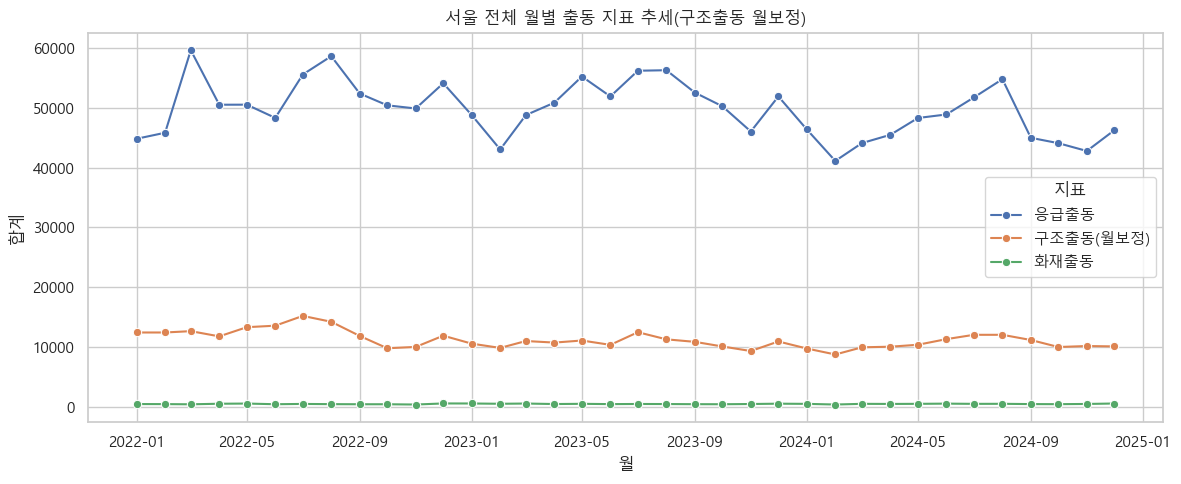

,연도,월,응급출동,구조출동_월보정,화재출동,date
0,2022,1,44825.0,12419.7,448.0,2022-01-01
1,2022,2,45833.0,12419.7,439.0,2022-02-01
2,2022,3,59635.0,12644.0,407.0,2022-03-01
3,2022,4,50520.0,11770.0,501.0,2022-04-01
4,2022,5,50529.0,13306.0,531.0,2022-05-01
5,2022,6,48319.0,13558.0,420.0,2022-06-01
6,2022,7,55575.0,15194.0,469.0,2022-07-01
7,2022,8,58640.0,14210.0,432.0,2022-08-01
8,2022,9,52391.0,11843.0,416.0,2022-09-01
9,2022,10,50419.0,9783.0,415.0,2022-10-01


In [7]:
monthly_city = dispatch_monthly.groupby(['연도', '월'], as_index=False)[['응급출동', '구조출동_월보정', '화재출동']].sum(min_count=1)
monthly_city['date'] = pd.to_datetime(dict(year=monthly_city['연도'], month=monthly_city['월'], day=1))
plot_df = monthly_city.melt(id_vars=['date', '연도', '월'], value_vars=['응급출동', '구조출동_월보정', '화재출동'], var_name='지표', value_name='값')
plot_df['지표'] = plot_df['지표'].replace({'구조출동_월보정': '구조출동(월보정)'})
plt.figure(figsize=(12, 5))
sns.lineplot(data=plot_df, x='date', y='값', hue='지표', marker='o')
plt.title('서울 전체 월별 출동 지표 추세(구조출동 월보정)')
plt.xlabel('월')
plt.ylabel('합계')
plt.tight_layout()
plt.show()
display(monthly_city.head(12))

## 분석 아이디어 5. 자치구별 안전 부담 지수 만들기

주민 체감 위험과 지역 안전도 비교를 위해 범죄 발생과 12개월 환산 출동 지표를 주민등록인구 1만 명당 지표로 바꾼 뒤, 낮은 검거율과 함께 표준화해 자치구별 주민 기준 안전 위험 점수를 구성합니다.

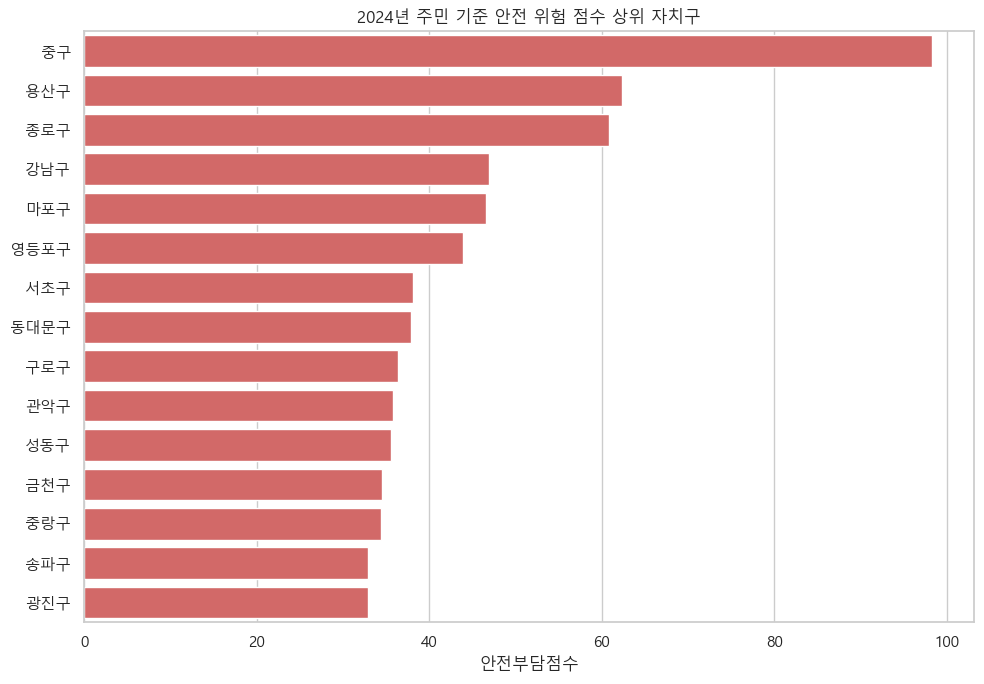

,자치구,연도,주민등록인구,발생,발생_1만명당,검거율,총출동지표_12개월환산,총출동지표_12개월환산_1만명당,주민안전위험점수,안전부담점수_25점
71,중구,2024,131214,2955,225.204628,0.737733,19149.0,1459.371713,98.224763,24.556191
62,용산구,2024,217194,3322,152.950818,0.745033,20549.0,946.112692,62.353450,15.588362
68,종로구,2024,149608,2765,184.816320,1.174684,20130.0,1345.516283,60.864780,15.216195
2,강남구,2024,563215,6107,108.431061,0.748322,46766.0,830.340101,46.917939,11.729485
38,마포구,2024,372745,3891,104.387718,0.779491,33651.0,902.788770,46.607577,11.651894
59,영등포구,2024,397173,4167,104.916497,0.803216,33960.0,855.043017,43.910056,10.977514
44,서초구,2024,413076,3788,91.702253,0.772967,30235.0,731.947632,38.065822,9.516455
32,동대문구,2024,358603,3216,89.681347,0.771766,26542.0,740.149971,37.880147,9.470037
20,구로구,2024,411916,3378,82.007011,0.729130,28232.0,685.382457,36.369238,9.092309
14,관악구,2024,495620,4485,90.492716,0.783946,34130.0,688.632420,35.744669,8.936167


In [8]:
def minmax(s):
    s = pd.to_numeric(s, errors='coerce')
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

score_base = merged.copy()
score_base['발생_총량_norm'] = score_base.groupby('연도')['발생'].transform(minmax)
score_base['미검거율_norm'] = score_base.groupby('연도')['검거율'].transform(lambda s: minmax(1 - s))
score_base['출동_총량_norm'] = score_base.groupby('연도')['총출동지표_12개월환산'].transform(minmax)
score_base['발생_1만명당_norm'] = score_base.groupby('연도')['발생_1만명당'].transform(minmax)
score_base['출동_1만명당_norm'] = score_base.groupby('연도')['총출동지표_12개월환산_1만명당'].transform(minmax)
score_base['주민안전위험점수'] = (score_base['발생_1만명당_norm'] * 0.45 + score_base['미검거율_norm'] * 0.25 + score_base['출동_1만명당_norm'] * 0.30) * 100
# 기존 후속 분석 코드는 안전부담점수 이름을 참조하므로 주민 기준 점수로 연결합니다.
score_base['발생_norm'] = score_base['발생_1만명당_norm']
score_base['출동_norm'] = score_base['출동_1만명당_norm']
score_base['안전부담점수'] = score_base['주민안전위험점수']
score_base['안전부담점수_25점'] = score_base['안전부담점수'] / 4
latest_year = int(score_base['연도'].max())
latest = score_base[score_base['연도'] == latest_year].sort_values('안전부담점수', ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(data=latest.head(15), x='안전부담점수', y='자치구', color='#E45756')
plt.title(f'{latest_year}년 주민 기준 안전 위험 점수 상위 자치구')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(latest[['자치구', '연도', '주민등록인구', '발생', '발생_1만명당', '검거율', '총출동지표_12개월환산', '총출동지표_12개월환산_1만명당', '주민안전위험점수', '안전부담점수_25점']].head(15))

### 가중치 민감도 분석

주민 기준 안전 위험 점수의 가중치가 임의 설정에 가까우므로, 여러 가중치 시나리오에서 상위 자치구가 얼마나 안정적으로 유지되는지 비교합니다. 순위가 크게 흔들리면 특정 가중치 가정에 민감한 지표로 해석하고, 반복적으로 상위권에 남는 자치구는 상대적으로 안정적인 고위험 지역으로 봅니다.

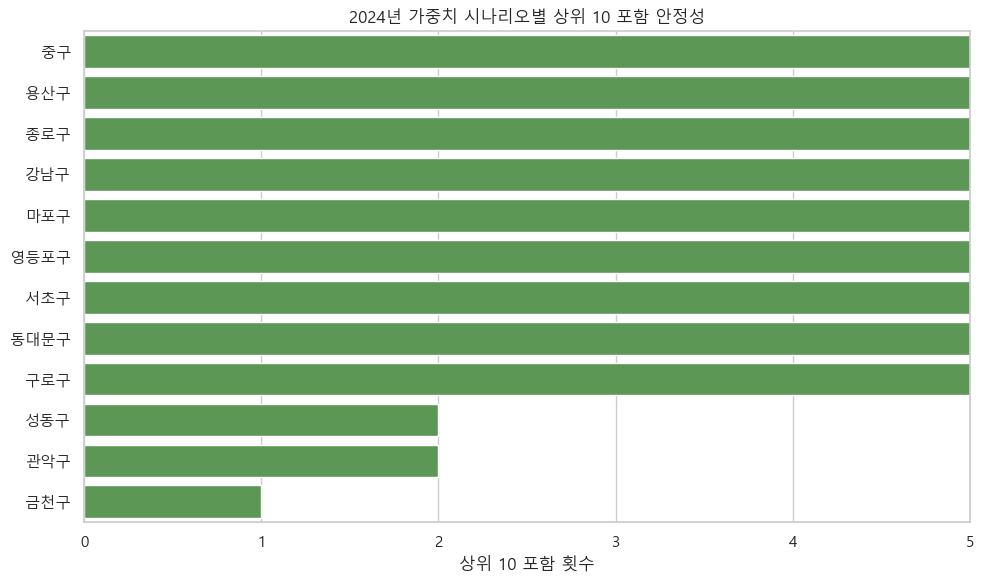

,시나리오,순위,자치구,점수
40,검거율강조안,1,중구,97.159621
41,검거율강조안,2,용산구,68.001553
42,검거율강조안,3,강남구,55.640612
43,검거율강조안,4,마포구,54.169587
44,검거율강조안,5,영등포구,50.947326
45,검거율강조안,6,종로구,48.797619
46,검거율강조안,7,성동구,48.114103
47,검거율강조안,8,구로구,48.009577
48,검거율강조안,9,서초구,47.498522
49,검거율강조안,10,동대문구,47.421607


,자치구,상위10_포함횟수,평균순위,최고순위
11,중구,5,1.0,1
9,용산구,5,2.4,2
10,종로구,5,3.2,2
0,강남구,5,4.0,3
5,마포구,5,4.6,4
8,영등포구,5,5.8,5
6,서초구,5,7.8,7
4,동대문구,5,8.0,7
2,구로구,5,9.2,8
7,성동구,2,8.5,7


In [9]:
weight_scenarios = {
    '현재안_발생중심': {'발생_norm': 0.45, '미검거율_norm': 0.25, '출동_norm': 0.30},
    '균등안': {'발생_norm': 1/3, '미검거율_norm': 1/3, '출동_norm': 1/3},
    '발생강조안': {'발생_norm': 0.50, '미검거율_norm': 0.20, '출동_norm': 0.30},
    '출동강조안': {'발생_norm': 0.35, '미검거율_norm': 0.20, '출동_norm': 0.45},
    '검거율강조안': {'발생_norm': 0.35, '미검거율_norm': 0.40, '출동_norm': 0.25},
}

sensitivity_base = score_base[score_base['연도'] == latest_year].copy()
rank_tables = []
top_n = 10

for scenario, weights in weight_scenarios.items():
    score_col = f'{scenario}_점수'
    rank_col = f'{scenario}_순위'
    sensitivity_base[score_col] = sum(sensitivity_base[col] * weight for col, weight in weights.items()) * 100
    sensitivity_base[rank_col] = sensitivity_base[score_col].rank(ascending=False, method='min').astype(int)
    top = sensitivity_base.nsmallest(top_n, rank_col)[['자치구', score_col, rank_col]].copy()
    top['시나리오'] = scenario
    top = top.rename(columns={score_col: '점수', rank_col: '순위'})
    rank_tables.append(top[['시나리오', '순위', '자치구', '점수']])

scenario_top = pd.concat(rank_tables, ignore_index=True)
top_stability = (
    scenario_top.groupby('자치구', as_index=False)
    .agg(상위10_포함횟수=('시나리오', 'nunique'), 평균순위=('순위', 'mean'), 최고순위=('순위', 'min'))
    .sort_values(['상위10_포함횟수', '평균순위'], ascending=[False, True])
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_stability.head(15), x='상위10_포함횟수', y='자치구', color='#54A24B')
plt.title(f'{latest_year}년 가중치 시나리오별 상위 10 포함 안정성')
plt.xlabel('상위 10 포함 횟수')
plt.ylabel('')
plt.xlim(0, len(weight_scenarios))
plt.tight_layout()
plt.show()

display(scenario_top.sort_values(['시나리오', '순위']))
display(top_stability.head(15))

## 분석 아이디어 6. 3년 평균 기반 안정적 순위

단일 연도의 우연한 변동을 줄이기 위해 2022~2024 평균으로 자치구별 주민 기준 안전 위험을 비교합니다. 출동 지표는 주민등록인구 1만 명당 12개월 환산값을 기준으로 합니다.

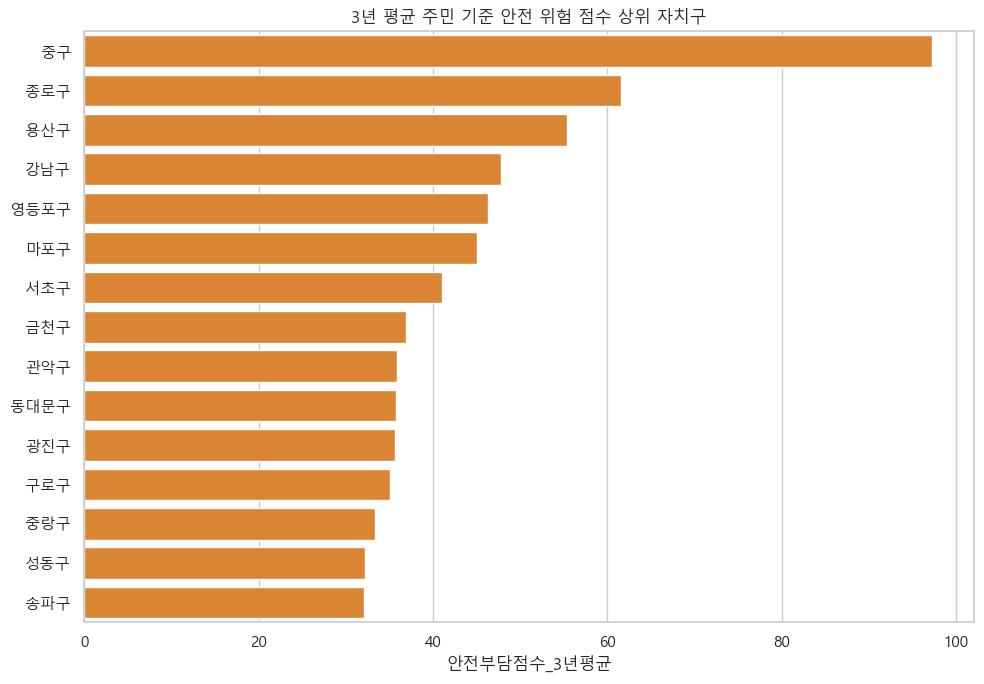

,자치구,주민등록인구_3년평균,발생_3년평균,발생_1만명당_3년평균,검거율_3년평균,총출동지표_12개월환산_3년평균,총출동지표_12개월환산_1만명당_3년평균,안전부담점수_3년평균,안전부담점수_25점_3년평균
23,중구,131264.000000,3124.666667,238.017408,0.721332,19763.600000,1505.659279,97.176654,24.294164
22,종로구,150757.333333,2961.333333,196.370823,1.130094,21200.333333,1406.009971,61.599621,15.399905
20,용산구,225861.333333,3103.333333,137.718812,0.733735,22568.933333,997.944662,55.369200,13.842300
0,강남구,549200.000000,6605.666667,120.466743,0.736357,49580.866667,903.959378,47.788975,11.947244
19,영등포구,397686.000000,4468.000000,112.343960,0.743662,36848.333333,926.515268,46.348574,11.587144
12,마포구,374497.333333,3940.333333,105.213369,0.739921,35141.133333,938.277860,45.091796,11.272949
14,서초구,411201.666667,4256.333333,103.535767,0.714000,32403.133333,788.166916,40.985066,10.246266
7,금천구,240997.666667,2278.000000,94.467682,0.787543,20448.333333,848.258696,36.889816,9.222454
4,관악구,498243.000000,4711.000000,94.539864,0.738711,36783.800000,738.101868,35.922589,8.980647
10,동대문구,357359.000000,3142.000000,87.948523,0.745249,28141.400000,787.750552,35.711768,8.927942


In [10]:
avg3 = score_base.groupby('자치구', as_index=False).agg(
    주민등록인구_3년평균=('주민등록인구', 'mean'),
    발생_3년평균=('발생', 'mean'),
    발생_1만명당_3년평균=('발생_1만명당', 'mean'),
    검거율_3년평균=('검거율', 'mean'),
    총출동지표_12개월환산_3년평균=('총출동지표_12개월환산', 'mean'),
    총출동지표_12개월환산_1만명당_3년평균=('총출동지표_12개월환산_1만명당', 'mean'),
    안전부담점수_3년평균=('안전부담점수', 'mean'),
    안전부담점수_25점_3년평균=('안전부담점수_25점', 'mean'),
).sort_values('안전부담점수_3년평균', ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(data=avg3.head(15), x='안전부담점수_3년평균', y='자치구', color='#F58518')
plt.title('3년 평균 주민 기준 안전 위험 점수 상위 자치구')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(avg3.head(15))

## 분석 아이디어 7. 전년 대비 변화율

최근에 범죄나 12개월 환산 출동 부담이 빠르게 증가한 자치구를 찾기 위해 전년 대비 변화율을 계산합니다.

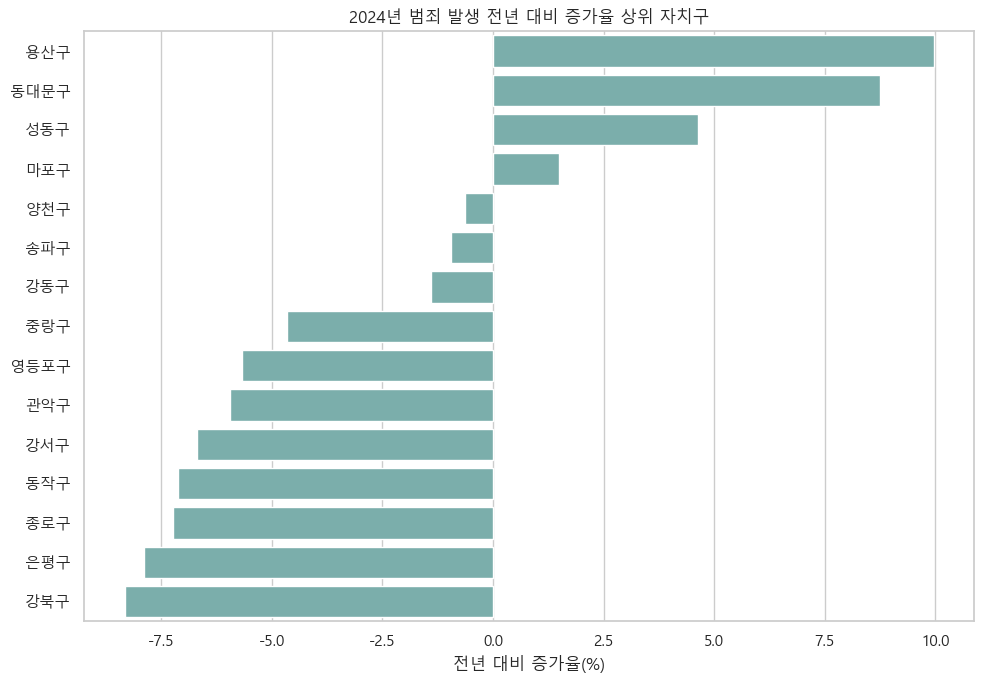

,자치구,연도,발생,발생_전년대비,검거율_전년대비,총출동지표_12개월환산_전년대비
62,용산구,2024,3322,9.963588,-0.760801,-8.699516
32,동대문구,2024,3216,8.758877,-0.820836,-5.433427
47,성동구,2024,2117,4.646565,2.264514,-6.401777
38,마포구,2024,3891,1.486698,3.482306,-7.762520
56,양천구,2024,3000,-0.629347,-0.403638,-5.956892
53,송파구,2024,5174,-0.938158,8.690140,-10.232454
5,강동구,2024,3350,-1.412596,2.042652,-6.829366
74,중랑구,2024,3169,-4.663057,4.424762,-9.260381
59,영등포구,2024,4167,-5.681304,4.771395,-8.426588
14,관악구,2024,4485,-5.955127,6.940526,-8.079720


In [11]:
change = merged.sort_values(['자치구', '연도']).copy()
for col in ['발생', '검거율', '총출동지표_12개월환산']:
    change[f'{col}_전년대비'] = change.groupby('자치구')[col].pct_change() * 100
latest_year = int(change['연도'].max())
latest_change = change[change['연도'] == latest_year].sort_values('발생_전년대비', ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(data=latest_change.head(15), x='발생_전년대비', y='자치구', color='#72B7B2')
plt.title(f'{latest_year}년 범죄 발생 전년 대비 증가율 상위 자치구')
plt.xlabel('전년 대비 증가율(%)')
plt.ylabel('')
plt.tight_layout()
plt.show()
display(latest_change[['자치구', '연도', '발생', '발생_전년대비', '검거율_전년대비', '총출동지표_12개월환산_전년대비']].head(15))

## 분석 아이디어 8. 자치구 클러스터링

범죄·검거율·출동 지표가 비슷한 자치구를 묶어 안전 이슈의 유형을 나눠봅니다.

- **복합 고부담형**: 범죄 발생과 12개월 환산 출동 부담이 함께 높아 종합 부담이 큰 유형입니다.
- **출동 집중형**: 범죄 발생 규모보다 12개월 환산 출동 부담이 상대적으로 두드러지는 유형입니다.
- **범죄 중심형**: 출동 부담보다 범죄 발생 규모가 상대적으로 두드러지는 유형입니다.
- **상대 저부담형**: 범죄 발생과 출동 부담이 모두 상대적으로 낮은 유형입니다.

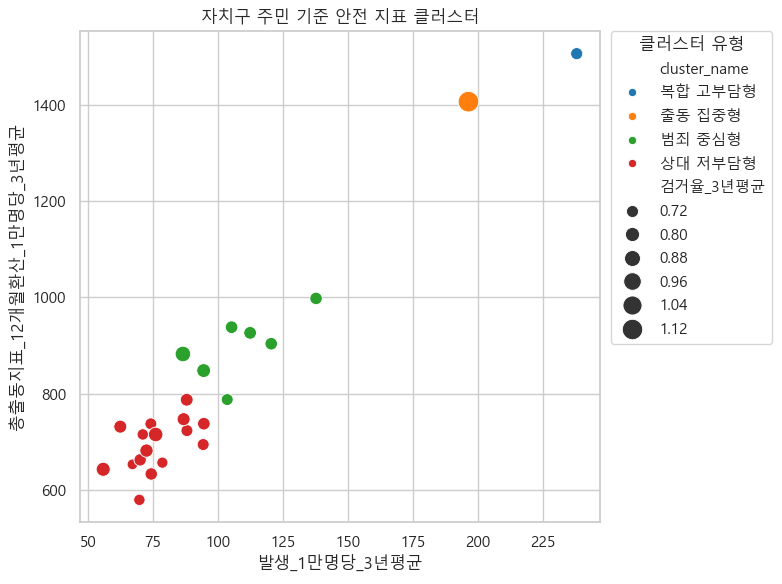

,cluster,cluster_name,발생_1만명당_3년평균,검거율_3년평균,총출동지표_12개월환산_1만명당_3년평균,안전부담점수_3년평균
3,3,복합 고부담형,238.017408,0.721332,1505.659279,97.176654
2,2,출동 집중형,196.370823,1.130094,1406.009971,61.599621
0,0,범죄 중심형,108.604667,0.759581,897.974478,43.482899
1,1,상대 저부담형,76.442385,0.732588,694.185889,30.325705


,자치구,주민등록인구_3년평균,발생_3년평균,발생_1만명당_3년평균,검거율_3년평균,총출동지표_12개월환산_3년평균,총출동지표_12개월환산_1만명당_3년평균,안전부담점수_3년평균,안전부담점수_25점_3년평균,cluster,cluster_name
2,강북구,293351.000000,2539.333333,86.486335,0.861851,25907.466667,882.698565,31.906864,7.976716,0,범죄 중심형
7,금천구,240997.666667,2278.000000,94.467682,0.787543,20448.333333,848.258696,36.889816,9.222454,0,범죄 중심형
14,서초구,411201.666667,4256.333333,103.535767,0.714000,32403.133333,788.166916,40.985066,10.246266,0,범죄 중심형
12,마포구,374497.333333,3940.333333,105.213369,0.739921,35141.133333,938.277860,45.091796,11.272949,0,범죄 중심형
19,영등포구,397686.000000,4468.000000,112.343960,0.743662,36848.333333,926.515268,46.348574,11.587144,0,범죄 중심형
0,강남구,549200.000000,6605.666667,120.466743,0.736357,49580.866667,903.959378,47.788975,11.947244,0,범죄 중심형
20,용산구,225861.333333,3103.333333,137.718812,0.733735,22568.933333,997.944662,55.369200,13.842300,0,범죄 중심형
23,중구,131264.000000,3124.666667,238.017408,0.721332,19763.600000,1505.659279,97.176654,24.294164,3,복합 고부담형
16,성북구,438396.333333,2448.000000,55.808002,0.795315,28216.200000,643.543045,20.166080,5.041520,1,상대 저부담형
3,강서구,568552.666667,4322.333333,75.987610,0.815369,40710.066667,715.713666,26.459157,6.614789,1,상대 저부담형


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_df = avg3.dropna(subset=['발생_1만명당_3년평균', '검거율_3년평균', '총출동지표_12개월환산_1만명당_3년평균']).copy()
features = ['발생_1만명당_3년평균', '검거율_3년평균', '총출동지표_12개월환산_1만명당_3년평균']
X = StandardScaler().fit_transform(cluster_df[features])
k = min(4, len(cluster_df))
cluster_df['cluster'] = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

cluster_profile = cluster_df.groupby('cluster', as_index=False).agg(
    발생_3년평균=('발생_3년평균', 'mean'),
    발생_1만명당_3년평균=('발생_1만명당_3년평균', 'mean'),
    검거율_3년평균=('검거율_3년평균', 'mean'),
    총출동지표_12개월환산_3년평균=('총출동지표_12개월환산_3년평균', 'mean'),
    총출동지표_12개월환산_1만명당_3년평균=('총출동지표_12개월환산_1만명당_3년평균', 'mean'),
    안전부담점수_3년평균=('안전부담점수_3년평균', 'mean'),
)
cluster_profile['발생_profile_norm'] = minmax(cluster_profile['발생_1만명당_3년평균'])
cluster_profile['출동_profile_norm'] = minmax(cluster_profile['총출동지표_12개월환산_1만명당_3년평균'])
cluster_profile['출동_발생_차이'] = cluster_profile['출동_profile_norm'] - cluster_profile['발생_profile_norm']

cluster_label_map = {}
high_cluster = cluster_profile.sort_values('안전부담점수_3년평균', ascending=False).iloc[0]['cluster']
low_cluster = cluster_profile.sort_values('안전부담점수_3년평균', ascending=True).iloc[0]['cluster']
cluster_label_map[high_cluster] = '복합 고부담형'
cluster_label_map[low_cluster] = '상대 저부담형'

middle_profile = cluster_profile[~cluster_profile['cluster'].isin([high_cluster, low_cluster])]
if not middle_profile.empty:
    dispatch_cluster = middle_profile.sort_values('출동_발생_차이', ascending=False).iloc[0]['cluster']
    cluster_label_map[dispatch_cluster] = '출동 집중형'
    for cluster_id in middle_profile['cluster']:
        cluster_label_map.setdefault(cluster_id, '범죄 중심형')

cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_label_map)
cluster_profile['cluster_name'] = cluster_profile['cluster'].map(cluster_label_map)
cluster_profile = cluster_profile.sort_values('안전부담점수_3년평균', ascending=False)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x='발생_1만명당_3년평균', y='총출동지표_12개월환산_1만명당_3년평균', hue='cluster_name', size='검거율_3년평균', palette='tab10', sizes=(60, 220))
plt.xlabel('발생_1만명당_3년평균')
plt.ylabel('총출동지표_12개월환산_1만명당_3년평균')
plt.title('자치구 주민 기준 안전 지표 클러스터')
plt.legend(title='클러스터 유형', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()
display(cluster_profile[['cluster', 'cluster_name', '발생_1만명당_3년평균', '검거율_3년평균', '총출동지표_12개월환산_1만명당_3년평균', '안전부담점수_3년평균']])
display(cluster_df.sort_values(['cluster_name', '안전부담점수_3년평균']))

## 분석 아이디어 9. 상위/하위 자치구 랭킹 대시보드형 표

주요 지표별 Top/Bottom 자치구를 한 번에 확인해 보고서나 발표용 표로 활용합니다.

In [13]:
rank_df = avg3.copy()
tables = {
    '범죄 발생 1만명당 3년 평균 Top 5': rank_df.nlargest(5, '발생_1만명당_3년평균')[['자치구', '발생_1만명당_3년평균']],
    '검거율 3년 평균 Bottom 5': rank_df.nsmallest(5, '검거율_3년평균')[['자치구', '검거율_3년평균']],
    '총출동지표 12개월 환산 1만명당 3년 평균 Top 5': rank_df.nlargest(5, '총출동지표_12개월환산_1만명당_3년평균')[['자치구', '총출동지표_12개월환산_1만명당_3년평균']],
    '주민 기준 안전 위험 점수 3년 평균 Top 5': rank_df.nlargest(5, '안전부담점수_3년평균')[['자치구', '안전부담점수_3년평균']],
}
for title, table in tables.items():
    print('\n' + title)
    display(table.reset_index(drop=True))


범죄 발생 1만명당 3년 평균 Top 5


,자치구,발생_1만명당_3년평균
0,중구,238.017408
1,종로구,196.370823
2,용산구,137.718812
3,강남구,120.466743
4,영등포구,112.343960



검거율 3년 평균 Bottom 5


,자치구,검거율_3년평균
0,동작구,0.673686
1,송파구,0.688738
2,양천구,0.694552
3,서대문구,0.695864
4,성동구,0.712882



총출동지표 12개월 환산 1만명당 3년 평균 Top 5


,자치구,총출동지표_12개월환산_1만명당_3년평균
0,중구,1505.659279
1,종로구,1406.009971
2,용산구,997.944662
3,마포구,938.277860
4,영등포구,926.515268



주민 기준 안전 위험 점수 3년 평균 Top 5


,자치구,안전부담점수_3년평균
0,중구,97.176654
1,종로구,61.599621
2,용산구,55.369200
3,강남구,47.788975
4,영등포구,46.348574


## 분석 아이디어 10. 범죄 지표와 출동 지표 간 상관관계

자치구·연도 기준 병합 테이블에서 범죄 지표(`발생`, `검거`)와 출동 지표(`응급출동`, `구조출동_12개월환산`, `화재출동`, `총출동지표_12개월환산`) 사이의 피어슨 상관계수를 확인합니다. 상관계수는 선형 관계의 방향과 강도를 보여주며, 인과관계를 의미하지는 않습니다.

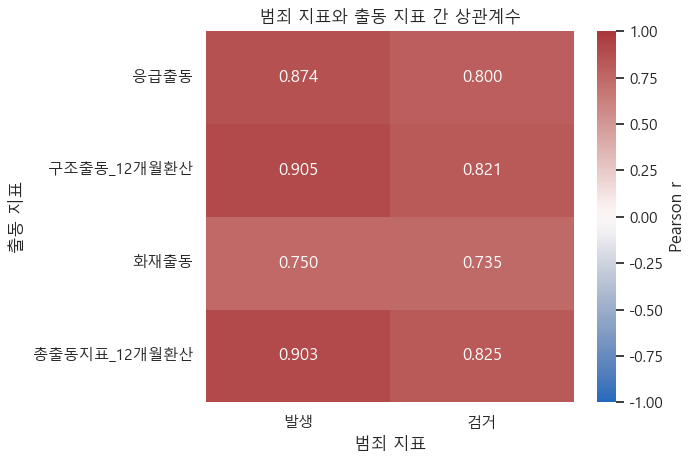

,출동지표,범죄지표,상관계수,절대상관
2,구조출동_12개월환산,발생,0.904676,0.904676
6,총출동지표_12개월환산,발생,0.902885,0.902885
0,응급출동,발생,0.874303,0.874303
7,총출동지표_12개월환산,검거,0.824911,0.824911
3,구조출동_12개월환산,검거,0.820769,0.820769
1,응급출동,검거,0.800242,0.800242
4,화재출동,발생,0.749910,0.749910
5,화재출동,검거,0.735440,0.735440


In [14]:
crime_metrics = ['발생', '검거']
dispatch_metrics = ['응급출동', '구조출동_12개월환산', '화재출동', '총출동지표_12개월환산']
corr_df = merged.dropna(subset=crime_metrics + dispatch_metrics).copy()

crime_dispatch_corr = corr_df[crime_metrics + dispatch_metrics].corr(numeric_only=True).loc[dispatch_metrics, crime_metrics]
top_corr = (
    crime_dispatch_corr.stack()
    .rename('상관계수')
    .reset_index()
    .rename(columns={'level_0': '출동지표', 'level_1': '범죄지표'})
    .assign(절대상관=lambda d: d['상관계수'].abs())
    .sort_values('절대상관', ascending=False)
)

plt.figure(figsize=(7, 4.8))
sns.heatmap(crime_dispatch_corr, annot=True, fmt='.3f', cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
plt.title('범죄 지표와 출동 지표 간 상관계수')
plt.xlabel('범죄 지표')
plt.ylabel('출동 지표')
plt.tight_layout()
plt.show()

display(top_corr)

## 추가 eda 분석과 통계검정

### 추가 분석 1. 자치구별 출동지표 비교

자치구별로 `응급출동`, `구조출동_12개월환산`, `화재출동`, `총출동지표_12개월환산`을 비교해 어떤 출동지표가 상대적으로 높은지 확인합니다. 평균·합계 기반 표와 막대그래프 또는 히트맵으로 자치구별 출동 특성을 비교할 예정입니다.

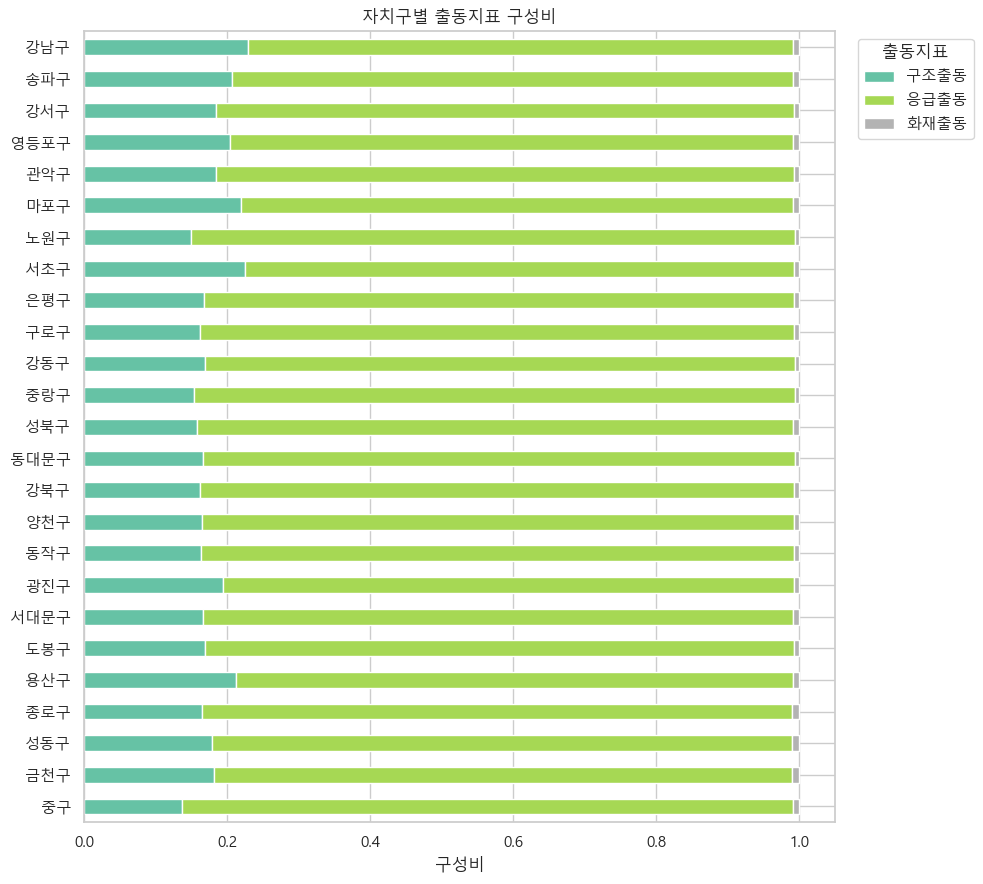

,자치구,응급출동_연평균,구조출동_12개월환산_연평균,화재출동_연평균,총출동지표_12개월환산_연평균,응급출동_비중,구조출동_비중,화재출동_비중,최대비중_출동지표
0,강남구,37788.000000,11377.533333,415.333333,49580.866667,0.762149,0.229474,0.008377,응급출동
17,송파구,34032.333333,9004.333333,373.666667,43410.333333,0.783968,0.207424,0.008608,응급출동
3,강서구,32929.000000,7510.733333,270.333333,40710.066667,0.808866,0.184493,0.006640,응급출동
19,영등포구,28996.666667,7540.666667,311.000000,36848.333333,0.786919,0.204641,0.008440,응급출동
4,관악구,29701.333333,6807.133333,275.333333,36783.800000,0.807457,0.185058,0.007485,응급출동
12,마포구,27166.333333,7690.800000,284.000000,35141.133333,0.773064,0.218855,0.008082,응급출동
8,노원구,28184.333333,4962.066667,179.666667,33326.066667,0.845714,0.148894,0.005391,응급출동
14,서초구,24888.666667,7278.466667,236.000000,32403.133333,0.768094,0.224622,0.007283,응급출동
21,은평구,26427.000000,5357.600000,218.666667,32003.266667,0.825759,0.167408,0.006833,응급출동
6,구로구,25003.333333,4854.800000,208.666667,30066.800000,0.831593,0.161467,0.006940,응급출동


In [15]:
dispatch_compare = (
    merged.groupby('자치구', as_index=False)[['응급출동', '구조출동_12개월환산', '화재출동', '총출동지표_12개월환산']]
    .mean()
    .rename(columns={
        '응급출동': '응급출동_연평균',
        '구조출동_12개월환산': '구조출동_12개월환산_연평균',
        '화재출동': '화재출동_연평균',
        '총출동지표_12개월환산': '총출동지표_12개월환산_연평균',
    })
)
share_cols = ['응급출동_비중', '구조출동_비중', '화재출동_비중']
dispatch_compare['응급출동_비중'] = dispatch_compare['응급출동_연평균'] / dispatch_compare['총출동지표_12개월환산_연평균']
dispatch_compare['구조출동_비중'] = dispatch_compare['구조출동_12개월환산_연평균'] / dispatch_compare['총출동지표_12개월환산_연평균']
dispatch_compare['화재출동_비중'] = dispatch_compare['화재출동_연평균'] / dispatch_compare['총출동지표_12개월환산_연평균']
dispatch_compare['최대비중_출동지표'] = dispatch_compare[share_cols].idxmax(axis=1).str.replace('_비중', '', regex=False)

dispatch_share_plot = dispatch_compare.sort_values('총출동지표_12개월환산_연평균', ascending=False)
share_long = dispatch_share_plot.melt(
    id_vars=['자치구'],
    value_vars=share_cols,
    var_name='출동지표',
    value_name='비중',
)
share_long['출동지표'] = share_long['출동지표'].str.replace('_비중', '', regex=False)
share_pivot = share_long.pivot(index='자치구', columns='출동지표', values='비중').loc[dispatch_share_plot['자치구']]

ax = share_pivot.plot(kind='barh', stacked=True, figsize=(10, 9), colormap='Set2')
ax.invert_yaxis()
plt.title('자치구별 출동지표 구성비')
plt.xlabel('구성비')
plt.ylabel('')
plt.legend(title='출동지표', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(dispatch_compare.sort_values('총출동지표_12개월환산_연평균', ascending=False).head(25))


### 추가 분석 2. 월별 출동 데이터와 연도 범죄지표 매칭 기반 상관 분석

자치구별 상관계수는 연도 관측치가 3개뿐이라 해석이 불안정하므로, 월별 출동 데이터를 같은 자치구·연도의 범죄지표와 매칭하는 보조 분석만 진행합니다. 월별 `응급출동`, `구조출동_월보정`, `화재출동`, `총출동지표_월보정`과 연도별 `발생`, `검거`, `검거율`의 관계를 탐색적으로 확인할 예정입니다.



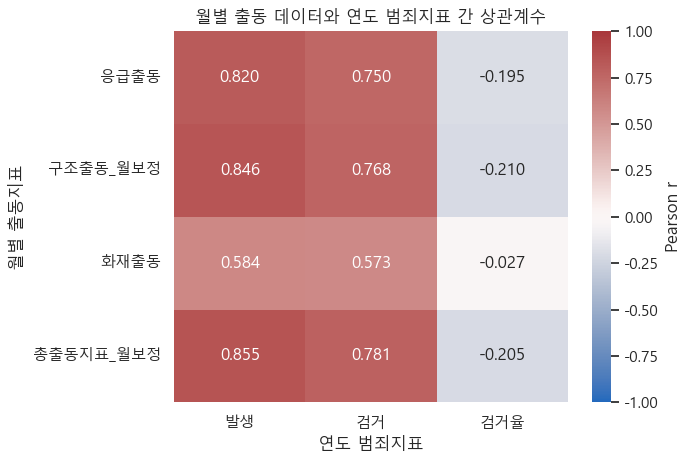

,월별출동지표,연도범죄지표,상관계수,절대상관
9,총출동지표_월보정,발생,0.855125,0.855125
3,구조출동_월보정,발생,0.846063,0.846063
0,응급출동,발생,0.819612,0.819612
10,총출동지표_월보정,검거,0.781276,0.781276
4,구조출동_월보정,검거,0.767593,0.767593
1,응급출동,검거,0.750183,0.750183
6,화재출동,발생,0.584194,0.584194
7,화재출동,검거,0.572922,0.572922
5,구조출동_월보정,검거율,-0.210300,0.210300
11,총출동지표_월보정,검거율,-0.204511,0.204511


In [16]:
crime_for_monthly = crime_yearly[~crime_yearly['자치구'].isin(TOTAL_NAMES)][['자치구', '연도', '발생', '검거', '검거율']].copy()
monthly_match = dispatch_monthly.merge(crime_for_monthly, on=['자치구', '연도'], how='inner')

monthly_dispatch_metrics = ['응급출동', '구조출동_월보정', '화재출동', '총출동지표_월보정']
monthly_crime_metrics = ['발생', '검거', '검거율']
monthly_corr = monthly_match[monthly_dispatch_metrics + monthly_crime_metrics].corr(numeric_only=True).loc[monthly_dispatch_metrics, monthly_crime_metrics]
monthly_top_corr = (
    monthly_corr.stack()
    .rename('상관계수')
    .reset_index()
    .rename(columns={'level_0': '월별출동지표', 'level_1': '연도범죄지표'})
    .assign(절대상관=lambda d: d['상관계수'].abs())
    .sort_values('절대상관', ascending=False)
)

plt.figure(figsize=(7, 4.8))
sns.heatmap(monthly_corr, annot=True, fmt='.3f', cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'})
plt.title('월별 출동 데이터와 연도 범죄지표 간 상관계수')
plt.xlabel('연도 범죄지표')
plt.ylabel('월별 출동지표')
plt.tight_layout()
plt.show()

display(monthly_top_corr)


### 추가 분석 2-1. 상관계수 유의성 검정

앞선 상관분석은 상관계수의 크기와 방향을 확인하는 데 그쳤으므로, 여기서는 피어슨 상관계수와 스피어만 순위상관계수에 대해 p-value를 함께 계산합니다. 여러 지표 조합을 동시에 검정하므로 FDR 보정을 적용해 우연히 유의하게 보일 가능성을 줄입니다. 피어슨은 선형 관계를, 스피어만은 순위 기반의 단조 관계를 확인하는 보완 지표로 해석합니다.


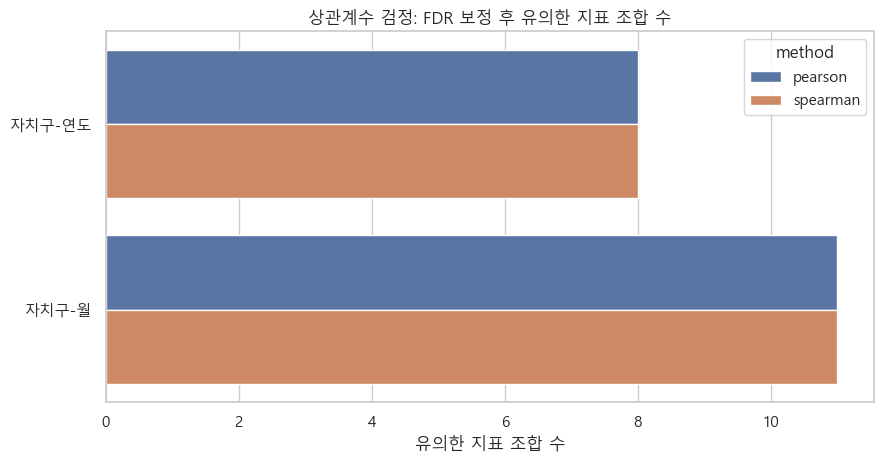

,자료범위,method,검정쌍수,유의쌍수_fdr_0_05,최소_p_fdr,최대_절대상관
0,자치구-연도,pearson,8,8,7.053402e-28,0.904676
1,자치구-연도,spearman,8,8,2.386812e-21,0.852453
2,자치구-월,pearson,12,11,2.279632e-257,0.855125
3,자치구-월,spearman,12,11,1.846942e-209,0.810204


,자료범위,method,출동지표,범죄지표,n,상관계수,p_value,p_fdr,유의여부_fdr_0.05
4,자치구-연도,pearson,구조출동_12개월환산,발생,75,0.904676,9.235234e-29,7.053402e-28,True
12,자치구-연도,pearson,총출동지표_12개월환산,발생,75,0.902885,1.763351e-28,7.053402e-28,True
0,자치구-연도,pearson,응급출동,발생,75,0.874303,1.286331e-24,3.430215e-24,True
14,자치구-연도,pearson,총출동지표_12개월환산,검거,75,0.824911,9.203735e-20,1.840747e-19,True
6,자치구-연도,pearson,구조출동_12개월환산,검거,75,0.820769,1.998500e-19,3.197599e-19,True
2,자치구-연도,pearson,응급출동,검거,75,0.800242,7.085498e-18,9.447330e-18,True
8,자치구-연도,pearson,화재출동,발생,75,0.749910,9.772056e-15,1.116806e-14,True
10,자치구-연도,pearson,화재출동,검거,75,0.735440,5.728566e-14,5.728566e-14,True
13,자치구-연도,spearman,총출동지표_12개월환산,발생,75,0.852453,2.983516e-22,2.386812e-21,True
5,자치구-연도,spearman,구조출동_12개월환산,발생,75,0.842069,2.943488e-21,1.177395e-20,True


In [17]:
from scipy.stats import pearsonr, spearmanr

def fdr_bh_corr(p_values):
    p = np.asarray(p_values, dtype=float)
    valid = np.isfinite(p)
    out = np.full_like(p, np.nan, dtype=float)
    if valid.sum() == 0:
        return out
    pv = p[valid]
    n = len(pv)
    order = np.argsort(pv)
    ranked = pv[order]
    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    restored = np.empty(n)
    restored[order] = adjusted
    out[valid] = restored
    return out

def correlation_significance_table(label, df, x_cols, y_cols, min_n=3):
    rows = []
    for x_col in x_cols:
        for y_col in y_cols:
            pair = df[[x_col, y_col]].dropna()
            n = len(pair)
            if n < min_n or pair[x_col].nunique() < 2 or pair[y_col].nunique() < 2:
                rows.append({
                    '자료범위': label,
                    '출동지표': x_col,
                    '범죄지표': y_col,
                    'method': 'pearson',
                    'n': n,
                    '상관계수': np.nan,
                    'p_value': np.nan,
                })
                rows.append({
                    '자료범위': label,
                    '출동지표': x_col,
                    '범죄지표': y_col,
                    'method': 'spearman',
                    'n': n,
                    '상관계수': np.nan,
                    'p_value': np.nan,
                })
                continue

            pearson_r, pearson_p = pearsonr(pair[x_col], pair[y_col])
            spearman_r, spearman_p = spearmanr(pair[x_col], pair[y_col])
            rows.extend([
                {
                    '자료범위': label,
                    '출동지표': x_col,
                    '범죄지표': y_col,
                    'method': 'pearson',
                    'n': n,
                    '상관계수': pearson_r,
                    'p_value': pearson_p,
                },
                {
                    '자료범위': label,
                    '출동지표': x_col,
                    '범죄지표': y_col,
                    'method': 'spearman',
                    'n': n,
                    '상관계수': spearman_r,
                    'p_value': spearman_p,
                },
            ])
    return pd.DataFrame(rows)

yearly_corr_test = correlation_significance_table(
    '자치구-연도',
    merged.dropna(subset=crime_metrics + dispatch_metrics),
    dispatch_metrics,
    crime_metrics,
)

monthly_corr_test = correlation_significance_table(
    '자치구-월',
    monthly_match.dropna(subset=monthly_dispatch_metrics + monthly_crime_metrics),
    monthly_dispatch_metrics,
    monthly_crime_metrics,
)

corr_test_all = pd.concat([yearly_corr_test, monthly_corr_test], ignore_index=True)
corr_test_all['p_fdr'] = np.nan
for _, idx in corr_test_all.groupby(['자료범위', 'method']).groups.items():
    corr_test_all.loc[idx, 'p_fdr'] = fdr_bh_corr(corr_test_all.loc[idx, 'p_value'].to_numpy())
corr_test_all['유의여부_fdr_0.05'] = corr_test_all['p_fdr'] < 0.05
corr_test_all['절대상관'] = corr_test_all['상관계수'].abs()

corr_test_summary = (
    corr_test_all.groupby(['자료범위', 'method'], as_index=False)
    .agg(
        검정쌍수=('p_fdr', 'size'),
        유의쌍수_fdr_0_05=('유의여부_fdr_0.05', 'sum'),
        최소_p_fdr=('p_fdr', 'min'),
        최대_절대상관=('절대상관', 'max'),
    )
    .sort_values(['자료범위', 'method'])
)

top_corr_tests = corr_test_all.sort_values(['자료범위', 'method', '절대상관'], ascending=[True, True, False])

plt.figure(figsize=(9, 4.8))
sns.barplot(data=corr_test_summary, x='유의쌍수_fdr_0_05', y='자료범위', hue='method')
plt.title('상관계수 검정: FDR 보정 후 유의한 지표 조합 수')
plt.xlabel('유의한 지표 조합 수')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(corr_test_summary)
display(top_corr_tests[['자료범위', 'method', '출동지표', '범죄지표', 'n', '상관계수', 'p_value', 'p_fdr', '유의여부_fdr_0.05']].head(30))


### 추가 분석 3. 자치구별 출동지표와 범죄지표 차이의 통계적 유의성 검정

자치구별 출동지표 차이와 범죄지표 차이가 통계적으로 유의미한지 검정합니다. 지표별 분포와 표본 수를 고려해 ANOVA, Kruskal-Wallis, permutation test 등 적절한 검정 방법을 비교해 사용할 예정입니다.



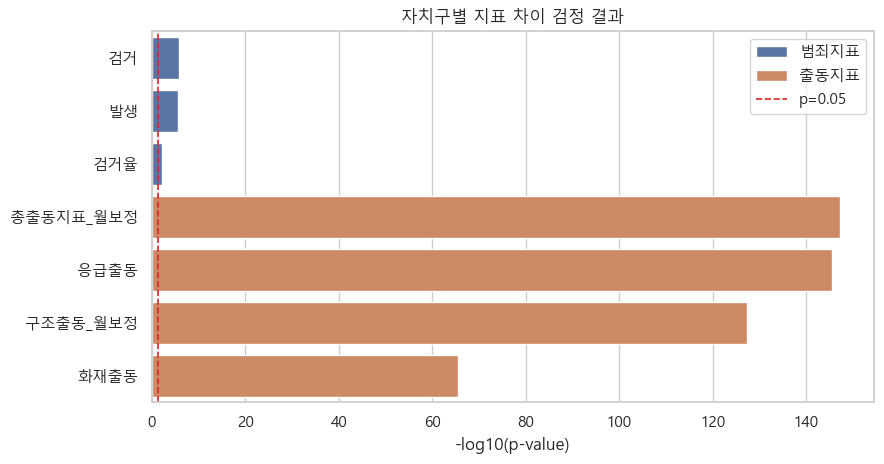

,구분,지표,검정,통계량,p_value,유의여부_0.05,-log10(p)
5,범죄지표,검거,Kruskal-Wallis,71.121901,1.476634e-06,True,5.830727
4,범죄지표,발생,Kruskal-Wallis,69.909415,2.256654e-06,True,5.646535
6,범죄지표,검거율,Kruskal-Wallis,45.032982,5.772983e-03,True,2.238600
3,출동지표,총출동지표_월보정,Kruskal-Wallis,773.538012,7.973786e-148,True,147.098335
0,출동지표,응급출동,Kruskal-Wallis,765.519136,3.920054e-146,True,145.406708
1,출동지표,구조출동_월보정,Kruskal-Wallis,679.088583,6.176629e-128,True,127.209248
2,출동지표,화재출동,Kruskal-Wallis,382.222045,3.312262e-66,True,65.479875


In [18]:
from scipy.stats import kruskal

# 출동지표: 자치구별 월별 관측치 기반 검정
monthly_test_df = dispatch_monthly[~dispatch_monthly['자치구'].isin(TOTAL_NAMES)].copy()
dispatch_test_metrics = ['응급출동', '구조출동_월보정', '화재출동', '총출동지표_월보정']

dispatch_test_results = []
for metric in dispatch_test_metrics:
    groups = [g[metric].dropna().values for _, g in monthly_test_df.groupby('자치구') if g[metric].dropna().shape[0] >= 2]
    stat, p_value = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    dispatch_test_results.append({
        '구분': '출동지표',
        '지표': metric,
        '검정': 'Kruskal-Wallis',
        '통계량': stat,
        'p_value': p_value,
        '유의여부_0.05': p_value < 0.05 if pd.notna(p_value) else np.nan,
    })

# 범죄지표: 자치구별 연도 관측치 기반 검정
crime_test_df = crime_yearly[~crime_yearly['자치구'].isin(TOTAL_NAMES)].copy()
crime_test_metrics = ['발생', '검거', '검거율']

crime_test_results = []
for metric in crime_test_metrics:
    groups = [g[metric].dropna().values for _, g in crime_test_df.groupby('자치구') if g[metric].dropna().shape[0] >= 2]
    stat, p_value = kruskal(*groups) if len(groups) >= 2 else (np.nan, np.nan)
    crime_test_results.append({
        '구분': '범죄지표',
        '지표': metric,
        '검정': 'Kruskal-Wallis',
        '통계량': stat,
        'p_value': p_value,
        '유의여부_0.05': p_value < 0.05 if pd.notna(p_value) else np.nan,
    })

test_results = pd.DataFrame(dispatch_test_results + crime_test_results).sort_values(['구분', 'p_value'])
test_results['-log10(p)'] = -np.log10(test_results['p_value'].clip(lower=1e-300))
plt.figure(figsize=(9, 4.8))
sns.barplot(data=test_results, x='-log10(p)', y='지표', hue='구분')
plt.axvline(-np.log10(0.05), color='#D62728', linestyle='--', linewidth=1.2, label='p=0.05')
plt.title('자치구별 지표 차이 검정 결과')
plt.xlabel('-log10(p-value)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

display(test_results)


### 추가 분석 4. 자치구별 안전부담점수 차이의 통계적 유의성 검정

자치구별 `안전부담점수` 차이가 유의미한지 검정합니다. 자치구당 연도 관측치가 적기 때문에 검정력 한계를 명시하고, 필요하면 비모수 검정 또는 permutation test를 함께 검토할 예정입니다.



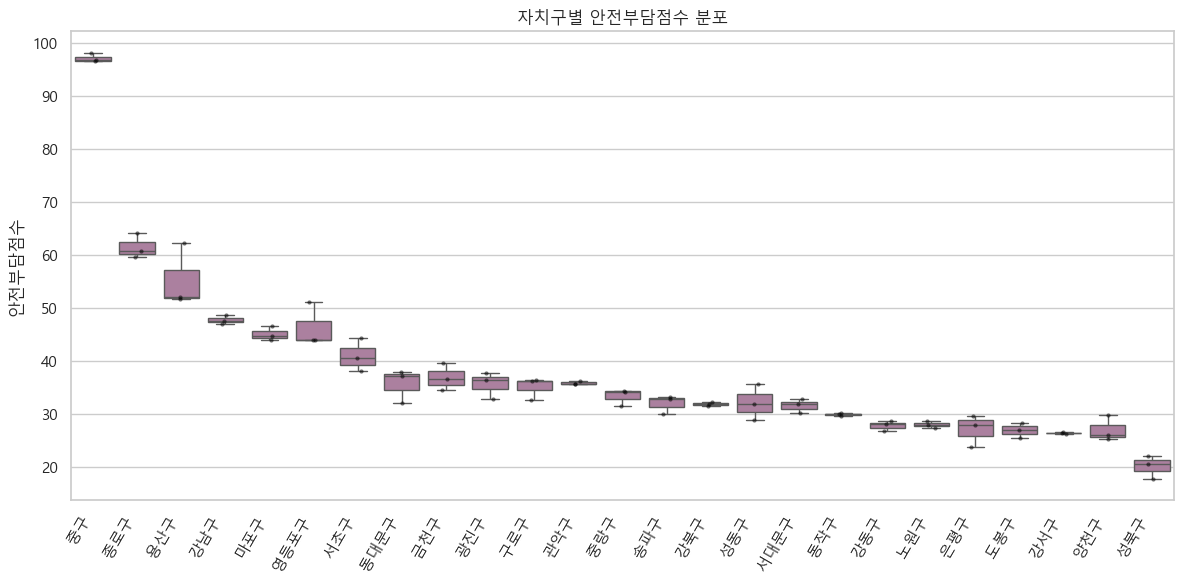

,지표,검정,통계량,p_value,유의여부_0.05,해석주의
0,안전부담점수,Kruskal-Wallis,70.472982,0.000002,True,자치구당 3개 연도 관측치 기반이므로 검정력이 낮음


,mean,median,std,count
자치구,,,,
중구,97.176654,96.741161,0.911999,3
종로구,61.599621,60.864780,2.387928,3
용산구,55.369200,52.053918,6.051123,3
강남구,47.788975,47.667179,0.937885,3
영등포구,46.348574,44.066949,4.088517,3
마포구,45.091796,44.655933,1.351627,3
서초구,40.985066,40.524440,3.174719,3
금천구,36.889816,36.572735,2.519478,3
관악구,35.922589,35.744669,0.357691,3


In [19]:
safety_test_df = score_base.dropna(subset=['자치구', '안전부담점수']).copy()
safety_groups = [g['안전부담점수'].dropna().values for _, g in safety_test_df.groupby('자치구') if g['안전부담점수'].dropna().shape[0] >= 2]
safety_stat, safety_p = kruskal(*safety_groups) if len(safety_groups) >= 2 else (np.nan, np.nan)

safety_test_result = pd.DataFrame([{
    '지표': '안전부담점수',
    '검정': 'Kruskal-Wallis',
    '통계량': safety_stat,
    'p_value': safety_p,
    '유의여부_0.05': safety_p < 0.05 if pd.notna(safety_p) else np.nan,
    '해석주의': '자치구당 3개 연도 관측치 기반이므로 검정력이 낮음',
}])

score_box_order = (
    safety_test_df.groupby('자치구')['안전부담점수']
    .median()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(12, 6))
sns.boxplot(data=safety_test_df, x='자치구', y='안전부담점수', order=score_box_order, color='#B279A2')
sns.stripplot(data=safety_test_df, x='자치구', y='안전부담점수', order=score_box_order, color='black', size=3, alpha=0.55)
plt.title('자치구별 안전부담점수 분포')
plt.xlabel('')
plt.ylabel('안전부담점수')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

display(safety_test_result)
display(safety_test_df.groupby('자치구')['안전부담점수'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))


## 추가 보완 분석. 관측값/보정값 비교, 부트스트랩 신뢰구간, 사후검정

앞선 추가 분석의 한계를 보완하기 위해 세 가지를 확인합니다. 첫째, 구조출동 결측 보정이 결과에 얼마나 영향을 주는지 관측값 기준과 보정값 기준을 비교합니다. 둘째, 자치구별 평균 지표에 부트스트랩 신뢰구간을 붙여 평균의 불확실성을 확인합니다. 셋째, Kruskal-Wallis 검정에서 유의한 지표에 대해 pairwise Mann-Whitney U 검정과 FDR 보정을 적용해 어느 자치구 쌍에서 차이가 큰지 탐색합니다.

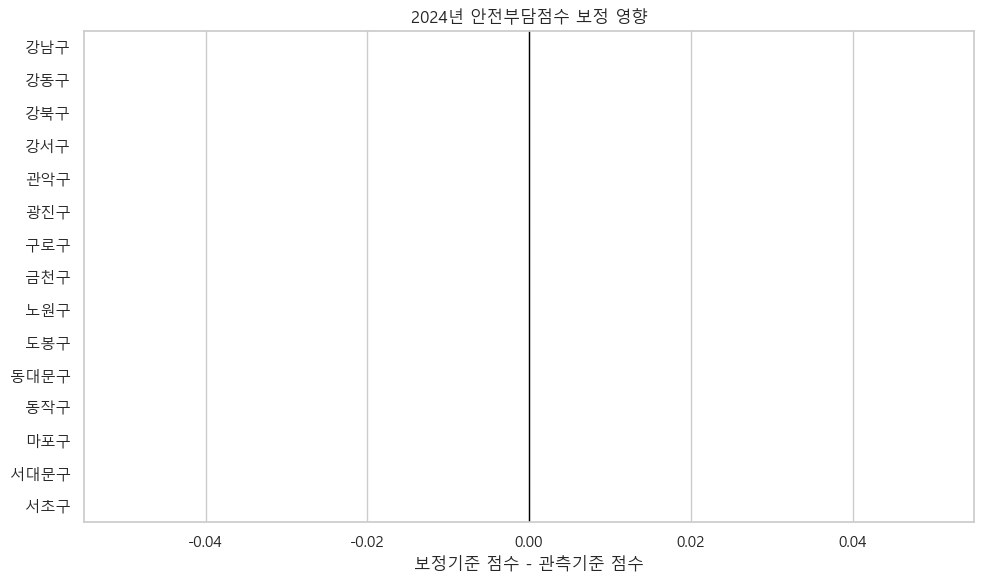

,자치구,연도,주민등록인구,총출동지표_관측합계,총출동지표_12개월환산,구조출동,구조출동_12개월환산,구조출동_관측월수,구조출동_결측월수,총출동지표_보정차이,총출동지표_보정차이율,총출동지표_관측합계_1만명당,총출동지표_12개월환산_1만명당,구조출동_보정차이
0,강남구,2022,534103,49451.0,51533.6,10413.0,12495.6,10,2,2082.6,4.211442,925.870104,964.862583,2082.6
60,용산구,2022,233284,23697.0,24650.8,4769.0,5722.8,10,2,953.8,4.024982,1015.800484,1056.686271,953.8
42,서초구,2022,408451,32429.0,33730.4,6507.0,7808.4,10,2,1301.4,4.013075,793.950804,825.812643,1301.4
57,영등포구,2022,398085,38023.0,39500.0,7385.0,8862.0,10,2,1477.0,3.884491,955.147770,992.250399,1477.0
36,마포구,2022,375585,34027.0,35289.4,6312.0,7574.4,10,2,1262.4,3.709995,905.973348,939.584914,1262.4
51,송파구,2022,664514,44136.0,45737.0,8005.0,9606.0,10,2,1601.0,3.627424,664.184652,688.277448,1601.0
15,광진구,2022,351252,25179.0,26091.8,4564.0,5476.8,10,2,912.8,3.625243,716.835776,742.822817,912.8
45,성동구,2022,288234,22184.0,22964.8,3904.0,4684.8,10,2,780.8,3.519654,769.652435,796.741536,780.8
21,금천구,2022,242818,20949.0,21630.0,3405.0,4086.0,10,2,681.0,3.250752,862.744937,890.790633,681.0
12,관악구,2022,501226,37869.0,39091.4,6112.0,7334.4,10,2,1222.4,3.227970,755.527447,779.915647,1222.4


,자치구,연도,안전부담점수_관측기준,안전부담점수_보정기준,안전부담점수_보정차이
2,강남구,2024,46.917939,46.917939,0.0
5,강동구,2024,28.698905,28.698905,0.0
8,강북구,2024,31.489211,31.489211,0.0
11,강서구,2024,26.582691,26.582691,0.0
14,관악구,2024,35.744669,35.744669,0.0
17,광진구,2024,32.840409,32.840409,0.0
20,구로구,2024,36.369238,36.369238,0.0
23,금천구,2024,34.543888,34.543888,0.0
26,노원구,2024,27.395653,27.395653,0.0
29,도봉구,2024,26.989058,26.989058,0.0


In [20]:
from itertools import combinations
from scipy.stats import mannwhitneyu

# 1) 관측값/보정값 비교: 연도 단위 총출동지표와 안전부담점수 민감도
observed_adjusted_compare = merged[['자치구', '연도', '주민등록인구', '총출동지표_관측합계', '총출동지표_12개월환산', '구조출동', '구조출동_12개월환산', '구조출동_관측월수', '구조출동_결측월수']].copy()
observed_adjusted_compare['총출동지표_보정차이'] = observed_adjusted_compare['총출동지표_12개월환산'] - observed_adjusted_compare['총출동지표_관측합계']
observed_adjusted_compare['총출동지표_보정차이율'] = np.where(
    observed_adjusted_compare['총출동지표_관측합계'] > 0,
    observed_adjusted_compare['총출동지표_보정차이'] / observed_adjusted_compare['총출동지표_관측합계'] * 100,
    np.nan,
)
observed_adjusted_compare['총출동지표_관측합계_1만명당'] = np.where(observed_adjusted_compare['주민등록인구'] > 0, observed_adjusted_compare['총출동지표_관측합계'] / observed_adjusted_compare['주민등록인구'] * 10000, np.nan)
observed_adjusted_compare['총출동지표_12개월환산_1만명당'] = np.where(observed_adjusted_compare['주민등록인구'] > 0, observed_adjusted_compare['총출동지표_12개월환산'] / observed_adjusted_compare['주민등록인구'] * 10000, np.nan)
observed_adjusted_compare['구조출동_보정차이'] = observed_adjusted_compare['구조출동_12개월환산'] - observed_adjusted_compare['구조출동']

score_compare = merged.copy()
score_compare['총출동지표_관측합계_1만명당'] = np.where(score_compare['주민등록인구'] > 0, score_compare['총출동지표_관측합계'] / score_compare['주민등록인구'] * 10000, np.nan)
score_compare['발생_norm'] = score_compare.groupby('연도')['발생_1만명당'].transform(minmax)
score_compare['미검거율_norm'] = score_compare.groupby('연도')['검거율'].transform(lambda s: minmax(1 - s))
score_compare['출동_norm_관측'] = score_compare.groupby('연도')['총출동지표_관측합계_1만명당'].transform(minmax)
score_compare['출동_norm_보정'] = score_compare.groupby('연도')['총출동지표_12개월환산_1만명당'].transform(minmax)
score_compare['안전부담점수_관측기준'] = (score_compare['발생_norm'] * 0.45 + score_compare['미검거율_norm'] * 0.25 + score_compare['출동_norm_관측'] * 0.30) * 100
score_compare['안전부담점수_보정기준'] = (score_compare['발생_norm'] * 0.45 + score_compare['미검거율_norm'] * 0.25 + score_compare['출동_norm_보정'] * 0.30) * 100
score_compare['안전부담점수_보정차이'] = score_compare['안전부담점수_보정기준'] - score_compare['안전부담점수_관측기준']

latest_score_compare = score_compare[score_compare['연도'] == score_compare['연도'].max()].sort_values('안전부담점수_보정차이', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=latest_score_compare.head(15), x='안전부담점수_보정차이', y='자치구', color='#4C78A8')
plt.axvline(0, color='black', linewidth=1)
plt.title(f"{int(score_compare['연도'].max())}년 안전부담점수 보정 영향")
plt.xlabel('보정기준 점수 - 관측기준 점수')
plt.ylabel('')
plt.tight_layout()
plt.show()

display(observed_adjusted_compare.sort_values(['연도', '총출동지표_보정차이율'], ascending=[True, False]).head(25))
display(latest_score_compare[['자치구', '연도', '안전부담점수_관측기준', '안전부담점수_보정기준', '안전부담점수_보정차이']].head(15))


### 부트스트랩 신뢰구간

자치구별 평균 총출동지표_12개월환산과 안전부담점수에 대해 부트스트랩 95% 신뢰구간을 계산합니다. 연도 수가 3개뿐인 지표는 구간이 거칠 수 있으므로, 평균의 불확실성을 보여주는 참고값으로 해석합니다.

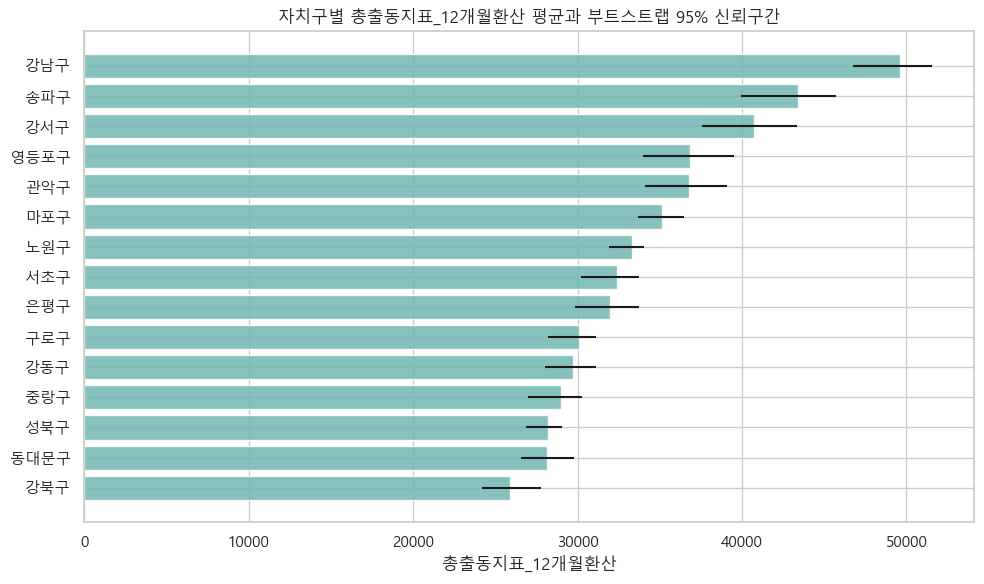

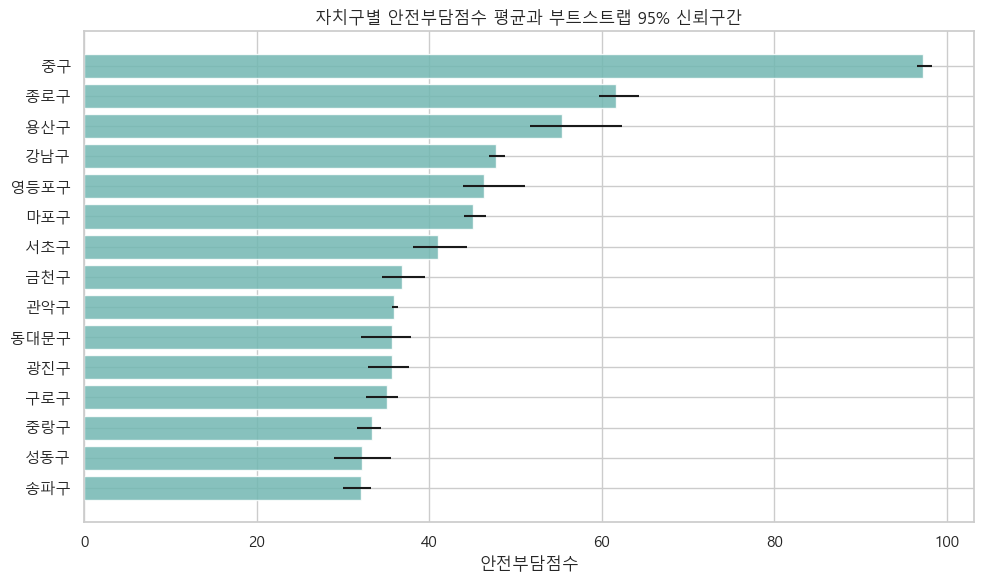

통계량,지표,자치구,mean,ci_low,ci_high,n
48,안전부담점수,중구,97.176654,96.564038,98.224763,3.0
47,안전부담점수,종로구,61.599621,59.665475,64.268607,3.0
45,안전부담점수,용산구,55.369200,51.700232,62.353450,3.0
25,안전부담점수,강남구,47.788975,46.917939,48.781808,3.0
44,안전부담점수,영등포구,46.348574,43.910056,51.068718,3.0
37,안전부담점수,마포구,45.091796,44.011879,46.607577,3.0
39,안전부담점수,서초구,40.985066,38.065822,44.364936,3.0
32,안전부담점수,금천구,36.889816,34.543888,39.552826,3.0
29,안전부담점수,관악구,35.922589,35.688747,36.334351,3.0
35,안전부담점수,동대문구,35.711768,32.098748,37.880147,3.0


In [21]:
def bootstrap_mean_ci(values, n_boot=5000, ci=95, random_state=42):
    values = pd.Series(values).dropna().to_numpy()
    if len(values) == 0:
        return pd.Series({'mean': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'n': 0})
    rng = np.random.default_rng(random_state)
    boot_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    alpha = (100 - ci) / 2
    return pd.Series({
        'mean': values.mean(),
        'ci_low': np.percentile(boot_means, alpha),
        'ci_high': np.percentile(boot_means, 100 - alpha),
        'n': len(values),
    })

bootstrap_targets = {
    '총출동지표_12개월환산': merged[['자치구', '총출동지표_12개월환산']].dropna(),
    '안전부담점수': score_base[['자치구', '안전부담점수']].dropna(),
}

bootstrap_tables = []
for metric, df_metric in bootstrap_targets.items():
    ci_table = (
        df_metric.groupby('자치구')[metric]
        .apply(lambda s: bootstrap_mean_ci(s, random_state=42))
        .reset_index()
        .rename(columns={'level_1': '통계량', metric: '값'})
        .pivot(index='자치구', columns='통계량', values='값')
        .reset_index()
    )
    ci_table['지표'] = metric
    bootstrap_tables.append(ci_table[['지표', '자치구', 'mean', 'ci_low', 'ci_high', 'n']])

bootstrap_ci = pd.concat(bootstrap_tables, ignore_index=True)

for metric in bootstrap_targets:
    plot_ci = bootstrap_ci[bootstrap_ci['지표'] == metric].sort_values('mean', ascending=False).head(15)
    xerr = np.vstack([plot_ci['mean'] - plot_ci['ci_low'], plot_ci['ci_high'] - plot_ci['mean']])
    plt.figure(figsize=(10, 6))
    plt.barh(plot_ci['자치구'], plot_ci['mean'], xerr=xerr, color='#72B7B2', alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f'자치구별 {metric} 평균과 부트스트랩 95% 신뢰구간')
    plt.xlabel(metric)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

display(bootstrap_ci.sort_values(['지표', 'mean'], ascending=[True, False]).head(30))


### 사후검정

Kruskal-Wallis 검정에서 유의한 지표를 대상으로 자치구 쌍별 Mann-Whitney U 검정을 수행하고, FDR 방식으로 다중비교를 보정합니다. 비교 쌍이 많고 표본 수가 작으므로, 보정 p-value와 효과크기를 함께 참고합니다.

# 데이터 검증 추가 섹션

위쪽은 원본 노트북의 전처리, 분석 아이디어, 가중치 민감도, 통계검정, 사후검정 흐름을 최대한 그대로 가져온 부분입니다. 아래부터는 최종 점수와 클러스터링 결과를 검증하기 위해 새로 추가한 데이터 검증 절차입니다.


## 데이터 검증 1. 구성요소와 안전부담점수 상관계수

안전부담점수는 세 구성요소의 가중합으로 만들어졌습니다. 따라서 최종 점수가 어떤 구성요소에 가장 크게 반응하는지, 구성요소끼리 지나치게 비슷하게 움직이는지 먼저 확인합니다. Pearson은 선형 관계, Spearman은 순위 관계를 보기 위해 함께 계산합니다.


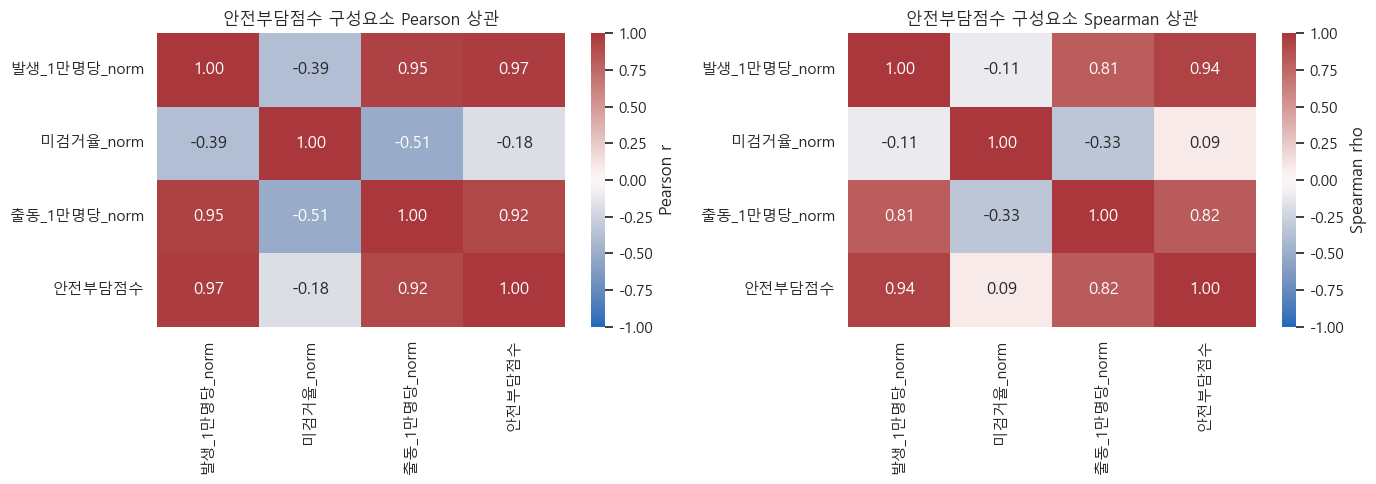

,발생_1만명당_norm,미검거율_norm,출동_1만명당_norm,안전부담점수
발생_1만명당_norm,1.00,-0.39,0.95,0.97
미검거율_norm,-0.39,1.00,-0.51,-0.18
출동_1만명당_norm,0.95,-0.51,1.00,0.92
안전부담점수,0.97,-0.18,0.92,1.00


,발생_1만명당_norm,미검거율_norm,출동_1만명당_norm,안전부담점수
발생_1만명당_norm,1.00,-0.11,0.81,0.94
미검거율_norm,-0.11,1.00,-0.33,0.09
출동_1만명당_norm,0.81,-0.33,1.00,0.82
안전부담점수,0.94,0.09,0.82,1.00


In [22]:
safety_score_validation_cols = [
    '발생_1만명당_norm',
    '미검거율_norm',
    '출동_1만명당_norm',
    '안전부담점수',
]

safety_score_validation = score_base[safety_score_validation_cols].dropna().copy()
pearson_corr = safety_score_validation.corr(method='pearson').round(2)
spearman_corr = safety_score_validation.corr(method='spearman').round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Pearson r'})
axes[0].set_title('안전부담점수 구성요소 Pearson 상관')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Spearman rho'})
axes[1].set_title('안전부담점수 구성요소 Spearman 상관')
plt.tight_layout()
plt.show()

display(pearson_corr)
display(spearman_corr)


## 데이터 검증 2. VIF 점검

VIF는 한 구성요소가 나머지 구성요소들로 얼마나 잘 설명되는지 확인하는 지표입니다. `VIF < 5`는 양호, `5 이상`은 주의, `10 이상`은 강한 다중공선성 가능성으로 해석합니다.


In [23]:
from sklearn.linear_model import LinearRegression

vif_features = ['발생_1만명당_norm', '미검거율_norm', '출동_1만명당_norm']
vif_data = score_base[vif_features].dropna().copy()

vif_rows = []
for target_col in vif_features:
    other_cols = [col for col in vif_features if col != target_col]
    model = LinearRegression()
    model.fit(vif_data[other_cols], vif_data[target_col])
    r2 = model.score(vif_data[other_cols], vif_data[target_col])
    vif = np.inf if np.isclose(1 - r2, 0) else 1 / (1 - r2)
    vif_rows.append({
        '변수': target_col,
        'R2': r2,
        'VIF': vif,
        '판정': '주의' if vif >= 5 else '양호',
    })

vif_result = pd.DataFrame(vif_rows)
vif_result[['R2', 'VIF']] = vif_result[['R2', 'VIF']].round(2)
display(vif_result)


,변수,R2,VIF,판정
0,발생_1만명당_norm,0.92,12.56,주의
1,미검거율_norm,0.38,1.61,양호
2,출동_1만명당_norm,0.93,14.54,주의


## 데이터 검증 3. 클러스터링 검증

원본 `분석 아이디어 8`에서 만든 클러스터링 결과가 어느 정도 타당한지 확인합니다. 여러 클러스터 수 후보를 비교하고, 현재 선택한 `k=4`의 품질을 함께 봅니다. Silhouette과 Calinski-Harabasz는 높을수록, Davies-Bouldin은 낮을수록 좋습니다.


In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

cluster_validation_rows = []
max_k = min(8, len(cluster_df) - 1)
for candidate_k in range(2, max_k + 1):
    labels = KMeans(n_clusters=candidate_k, random_state=42, n_init=50).fit_predict(X)
    cluster_validation_rows.append({
        '클러스터수': candidate_k,
        'Silhouette': silhouette_score(X, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X, labels),
        'Davies_Bouldin': davies_bouldin_score(X, labels),
        '현재선택': candidate_k == k,
    })

cluster_validation = pd.DataFrame(cluster_validation_rows)
metric_cols = ['Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin']
cluster_validation[metric_cols] = cluster_validation[metric_cols].round(2)

current_cluster_size = (
    cluster_df.groupby('cluster_name', as_index=False)
    .agg(
        자치구수=('자치구', 'count'),
        평균_안전부담점수_3년평균=('안전부담점수_3년평균', 'mean'),
    )
    .sort_values('평균_안전부담점수_3년평균', ascending=False)
)
current_cluster_size['평균_안전부담점수_3년평균'] = current_cluster_size['평균_안전부담점수_3년평균'].round(2)

display(cluster_validation)
display(current_cluster_size)


,클러스터수,Silhouette,Calinski_Harabasz,Davies_Bouldin,현재선택
0,2,0.75,38.03,0.63,False
1,3,0.72,39.06,0.14,False
2,4,0.39,53.73,0.52,True
3,5,0.40,59.91,0.55,False
4,6,0.30,63.90,0.61,False
5,7,0.35,80.18,0.57,False
6,8,0.31,76.61,0.47,False


,cluster_name,자치구수,평균_안전부담점수_3년평균
1,복합 고부담형,1,97.18
3,출동 집중형,1,61.60
0,범죄 중심형,7,43.48
2,상대 저부담형,16,30.33


## 데이터 검증 4. 재현성 검증

안전부담점수 산식은 결정론적 계산이므로 기존 점수와 재계산 점수의 차이가 없어야 합니다. KMeans는 초기값에 영향을 받을 수 있으므로 여러 seed에서 군집 배정이 얼마나 안정적인지 `Adjusted Rand Index`로 확인합니다.


In [25]:
from sklearn.metrics import adjusted_rand_score

recalc_score = (
    score_base['발생_1만명당_norm'] * 0.45
    + score_base['미검거율_norm'] * 0.25
    + score_base['출동_1만명당_norm'] * 0.30
) * 100

score_repro_check = pd.DataFrame({
    '검증항목': ['안전부담점수 재계산 최대차이', '안전부담점수_25점 재계산 최대차이'],
    '값': [
        (score_base['안전부담점수'] - recalc_score).abs().max(),
        (score_base['안전부담점수_25점'] - recalc_score / 4).abs().max(),
    ],
})
score_repro_check['값'] = score_repro_check['값'].round(2)

base_labels = KMeans(n_clusters=k, random_state=42, n_init=50).fit_predict(X)
seed_rows = []
for seed in [0, 1, 7, 42, 100, 2024, 2025]:
    labels = KMeans(n_clusters=k, random_state=seed, n_init=50).fit_predict(X)
    seed_rows.append({
        'seed': seed,
        'ARI_vs_seed_42': adjusted_rand_score(base_labels, labels),
        'Silhouette': silhouette_score(X, labels),
        'Davies_Bouldin': davies_bouldin_score(X, labels),
    })

cluster_repro_check = pd.DataFrame(seed_rows)
cluster_repro_check[['ARI_vs_seed_42', 'Silhouette', 'Davies_Bouldin']] = (
    cluster_repro_check[['ARI_vs_seed_42', 'Silhouette', 'Davies_Bouldin']].round(2)
)

display(score_repro_check)
display(cluster_repro_check)


,검증항목,값
0,안전부담점수 재계산 최대차이,0.0
1,안전부담점수_25점 재계산 최대차이,0.0


,seed,ARI_vs_seed_42,Silhouette,Davies_Bouldin
0,0,1.0,0.39,0.52
1,1,1.0,0.39,0.52
2,7,1.0,0.39,0.52
3,42,1.0,0.39,0.52
4,100,1.0,0.39,0.52
5,2024,1.0,0.39,0.52
6,2025,1.0,0.39,0.52
